# 1. 전처리

In [3]:
import numpy as np
import pandas as pd   
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.metrics import f1_score, accuracy_score, precision_score, recall_score, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# ============================================================
# 1. 데이터 로드
# ============================================================
df = pd.read_csv('univ355.csv')  
#¹ 연구 대상자 355명의 원자료 로드


# ============================================================
# 2. 대량 결측치 또는 의미 부족 변수 제거
# ============================================================
drop_missing_cols = [
    'why_not_rechoice', 'future_job_desc', 'income_class', 'income_contest',
    'income_perf', 'income_broadcast', 'income_studio', 'income_creator',
    'income_choreo', 'info_dept', 'info_career_center', 'info_online',
    'info_family', 'info_friends', 'info_academy', 'info_self',
    'help_financial', 'help_resume', 'help_career', 'help_social',
    'help_no', 'non_stay_reason', 'total_univ', 'id'
]
df = df.drop(columns=drop_missing_cols, errors='ignore')
#² 설문에서 무응답 비율이 높거나, 예측모형 기여도가 낮은 변수들을 선제적으로 제거하여 모델 안정성 확보


# ============================================================
# 3. 지역 관련 중복 변수 제거
# ============================================================
current_area_cols = [col for col in df.columns if col.startswith('current_area')]
df = df.drop(columns=current_area_cols, errors='ignore')
#³ 지역 중복 측정 항목은 multicollinearity를 유발하므로 제거


# ============================================================
# 4. 오타 및 잘못된 범주값 정정
# ============================================================
if 'birth_area' in df.columns:
    df['birth_area'] = df['birth_area'].replace({'g': 'gangwon'})  
#⁴ 데이터 입력 과정에서 발생한 코드형 오타(g) → 정식 표기 값(gangwon)으로 교정


# ============================================================
# 5. 범주형 변수 매핑 및 원-핫 인코딩
# ============================================================

# 5-1) 무용경력 구간(midpoint) 변환
midpoint_map = {'less2':1, '2to4':2, '4to7':3, '7to10':4, 'over10':5}
if 'dance_years' in df.columns:
    df['dance_years'] = df['dance_years'].map(midpoint_map)
#⁵ 구간형 변수(dance_years)를 중간값 기반 수치형으로 변환하여 순서 정보 유지 및 모델 활용도 증가


# 5-2) 범주형 변수 원-핫 인코딩
columns_to_encode = [
    'univ_factor', 'major_factor', 'job_region', 'weight_control',
    'birth_area', 'housing_type', 'enter_type',
    'major_detail', 'univ_name', 'univ_area'
]
df = pd.get_dummies(df, columns=columns_to_encode, drop_first=False, dtype=float)
#⁶ 범주형 변수를 ML 모델에서 활용하기 위해 원-핫 인코딩 실시 (drop_first=False: 정보 손실 방지)


# ============================================================
# 6. 사전 정의된 분석 제외 변수 제거
# ============================================================
remove_vars = ["prof_hi", "int_major", "enter_year"]
df = df.drop(columns=remove_vars, errors='ignore')
#⁷ 이론적 타당성 부족 또는 중복 의미를 갖는 변수는 제거하여 모델 해석 명확성 제고


# ============================================================
# 7. 다중공선성 우려 변수 사전 제거
# ============================================================
high_corr_remove = ['lecture_qual', 'peer_personal', 'enjoy_major', 'prof_chat','peer_study']
df = df.drop(columns=high_corr_remove, errors='ignore')
#⁸ 상관계수가 높은 변수들을 사전 제거하여 다중공선성 완화 및 변수선택 과정의 안정성 확보


# ============================================================
# 8. 대학·전공만족도(sat) 지표 생성 및 이진화
# ============================================================
sat_cols = ['univ_proud', 'univ_belong', 'major_proud', 'major_belong']
df['sat'] = df[sat_cols].mean(axis=1)
#⁹ 학습자 만족도를 의미하는 4개 문항의 평균값으로 composite indicator 생성

sat_median = df['sat'].median()
df['sat_group'] = (df['sat'] >= sat_median).astype(int)
#¹⁰ 만족도 분포의 왜도 보정을 위해 중앙값 기준으로 고·저 만족 그룹을 이진화

# ============================================================
# 9. 설명용 출력
# ============================================================
print("✅ 최종 데이터셋 컬럼 수:", df.shape[1])
print("sat 중위수:", sat_median)
print(df[['sat', 'sat_group']].head())
#¹¹ 최종 전처리 결과 확인용 출력


✅ 최종 데이터셋 컬럼 수: 177
sat 중위수: 4.0
    sat  sat_group
0  4.00          1
1  4.50          1
2  3.00          0
3  3.00          0
4  4.75          1


# 2. 데이터 분할 및 변수선택

In [4]:
# ======================================
# ✅ 2번 코드 (최종 정석: 6:2:2 split + Train 내부 5-fold 변수선택)
# - 먼저 train/val/test = 6:2:2 분할 (누수 방지)
# - 변수선택 비교는 train에서만 5-fold로 수행
# - 방법별:
#   * fold별 선택변수 저장
#   * 5fold 교집합 변수 산출
#   * 안정성: Jaccard(폴드간 평균 pairwise)
#   * 성능: CV F1 / CV ROC-AUC (5fold 평균±표준편차)
# - 결과표로 비교 후, 상위 2개 방법의 교집합 변수를 3번 코드에서 모델링에 사용
# ======================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) df 체크 & X, y 구성
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")

target_col = "sat_group"
if target_col not in df.columns:
    raise RuntimeError("sat_group이 없습니다. 1번 코드에서 sat_group 생성 후 실행하세요.")

y_all = df[target_col].copy()

# 타깃 생성에 사용된 변수 제거(누수 방지)
drop_target_related = ["sat", "sat_group", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_all = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()

# -------------------------
# 1) ✅ 6:2:2 분할 (Stratify 유지)
# -------------------------
# (1) train+val(80) vs test(20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE
)

# (2) train(60) vs val(20)  -> train_val의 25%가 val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)

print(f"✅ Split 완료 | Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# -------------------------
# 2) Jaccard 평균(pairwise)
# -------------------------
def mean_pairwise_jaccard(list_of_sets):
    if len(list_of_sets) < 2:
        return np.nan
    vals = []
    for i in range(len(list_of_sets)):
        for j in range(i + 1, len(list_of_sets)):
            a, b = list_of_sets[i], list_of_sets[j]
            inter = len(a & b)
            union = len(a | b)
            vals.append(inter / union if union > 0 else 0.0)
    return float(np.mean(vals)) if vals else np.nan

# -------------------------
# 3) fold 실행 함수들 (방법별 변수선택 + fold 성능평가)
# -------------------------
def elasticnet_select_and_eval(X_tr, y_tr, X_va, y_va):
    """
    ElasticNet(LR-CV)로 변수선택 + LR로 fold 성능평가
    - 스케일링: fold train에서만 fit (Pipeline)
    - 성능: F1, ROC-AUC (표준: 1 기준 점수)
    """
    selector = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegressionCV(
            Cs=20,
            cv=5,
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.5],
            max_iter=10000,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])
    selector.fit(X_tr, y_tr)
    coef = selector.named_steps["clf"].coef_.ravel()
    sel_cols = list(X_tr.columns[coef != 0])

    if len(sel_cols) == 0:
        return set(), np.nan, np.nan

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE))
    ])
    model.fit(X_tr[sel_cols], y_tr)

    y_pred = model.predict(X_va[sel_cols])
    f1 = f1_score(y_va, y_pred)

    try:
        y_score = model.predict_proba(X_va[sel_cols])[:, 1]
        auc = roc_auc_score(y_va, y_score)
    except Exception:
        auc = np.nan

    return set(sel_cols), f1, auc


def rfecv_select_and_eval(method, X_tr, y_tr, X_va, y_va):
    """
    RFECV로 변수선택 + 같은 모델로 fold 성능평가
    - RFECV scoring: 'f1' (기본 1 기준)
    - 성능: F1, ROC-AUC (표준: 1 기준 점수)
    """
    if method == "LR":
        base = LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE)
        selector = Pipeline([
            ("scaler", StandardScaler()),
            ("rfecv", RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1))
        ])
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE))
        ])

    elif method == "DT":
        base = DecisionTreeClassifier(random_state=RANDOM_STATE)
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        model = DecisionTreeClassifier(random_state=RANDOM_STATE)

    elif method == "RF":
        base = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)

    elif method == "XGB":
        base = XGBClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1
        )
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        model = XGBClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1
        )
    else:
        raise ValueError("method는 'LR','DT','RF','XGB' 중 하나여야 합니다.")

    selector.fit(X_tr, y_tr)

    if isinstance(selector, Pipeline):
        support = selector.named_steps["rfecv"].support_
    else:
        support = selector.support_

    sel_cols = list(X_tr.columns[support])
    if len(sel_cols) == 0:
        return set(), np.nan, np.nan

    model.fit(X_tr[sel_cols], y_tr)

    y_pred = model.predict(X_va[sel_cols])
    f1 = f1_score(y_va, y_pred)

    try:
        y_score = model.predict_proba(X_va[sel_cols])[:, 1]
        auc = roc_auc_score(y_va, y_score)
    except Exception:
        auc = np.nan

    return set(sel_cols), f1, auc

# -------------------------
# 4) ✅ Train 내부에서만 5-fold 실행
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

methods = ["ElasticNet", "RFECV(LR)", "RFECV(DT)", "RFECV(RF)", "RFECV(XGB)"]

fold_sets = {m: [] for m in methods}
fold_f1 = {m: [] for m in methods}
fold_auc = {m: [] for m in methods}

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    # ElasticNet
    sel, f1, auc = elasticnet_select_and_eval(X_tr, y_tr, X_va, y_va)
    fold_sets["ElasticNet"].append(sel)
    fold_f1["ElasticNet"].append(f1)
    fold_auc["ElasticNet"].append(auc)

    # RFECV family
    for short in ["LR", "DT", "RF", "XGB"]:
        key = f"RFECV({short})"
        sel, f1, auc = rfecv_select_and_eval(short, X_tr, y_tr, X_va, y_va)
        fold_sets[key].append(sel)
        fold_f1[key].append(f1)
        fold_auc[key].append(auc)

# -------------------------
# 5) 요약표 + 교집합 변수 출력 + 3번 코드용 변수 저장
# -------------------------
summary_rows = []
intersection_vars = {}

for m in methods:
    sets_ = fold_sets[m]
    inter = set.intersection(*sets_) if len(sets_) > 0 else set()
    intersection_vars[m] = sorted(list(inter))

    summary_rows.append({
        "방법": m,
        "안정적 변수 수(교집합)": len(inter),
        "CV_F1_mean": float(np.nanmean(fold_f1[m])),
        "CV_F1_std": float(np.nanstd(fold_f1[m])),
        "CV_ROC_AUC_mean": float(np.nanmean(fold_auc[m])),
        "CV_ROC_AUC_std": float(np.nanstd(fold_auc[m])),
        "Jaccard_mean": mean_pairwise_jaccard(sets_),
    })

fs_table = pd.DataFrame(summary_rows).sort_values(
    by=["CV_F1_mean", "CV_ROC_AUC_mean", "Jaccard_mean"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n✅ [표] 변수선택 방법 비교 (Train 내부 5-fold)")
display(fs_table)

print("\n✅ [리스트] 방법별 5-fold 교집합 변수 (Train 내부에서만 산출)")
for m in methods:
    print(f"\n--- {m} (교집합 {len(intersection_vars[m])}개) ---")
    print(intersection_vars[m])

# ✅ 3번 코드에서 쓰기 좋게: 상위 2개 방법 자동 선택
selected_fs_methods = fs_table["방법"].iloc[:2].tolist()
selected_feature_sets = {m: intersection_vars[m] for m in selected_fs_methods}

print("\n✅ [3번코드 참고] 추천 변수선택방법 TOP2:", selected_fs_methods)
for m in selected_fs_methods:
    print(f"- {m}: 교집합 변수 {len(selected_feature_sets[m])}개")

# ✅ 3번 코드에서 그대로 쓰라고 분할 데이터도 남겨둠
# X_train, X_val, X_test, y_train, y_val, y_test


✅ Split 완료 | Train: (213, 171), Val: (71, 171), Test: (71, 171)

✅ [표] 변수선택 방법 비교 (Train 내부 5-fold)


,방법,안정적 변수 수(교집합),CV_F1_mean,CV_F1_std,CV_ROC_AUC_mean,CV_ROC_AUC_std,Jaccard_mean
0,RFECV(RF),10,0.850407,0.038395,0.864889,0.069945,0.413629
1,RFECV(XGB),8,0.814143,0.051664,0.840837,0.053567,0.369871
2,ElasticNet,14,0.809383,0.040554,0.826271,0.038513,0.416336
3,RFECV(LR),1,0.777824,0.061351,0.809727,0.038604,0.114712
4,RFECV(DT),0,0.773489,0.058020,0.753822,0.071693,0.136190



✅ [리스트] 방법별 5-fold 교집합 변수 (Train 내부에서만 산출)

--- ElasticNet (교집합 14개) ---
['course_variety', 'exercise_reg', 'exp_concours', 'exp_video', 'peer_advice', 'peer_event', 'prof_access', 'prof_passion', 'student_interact', 'students_diligent', 'theory_cls', 'time_eff', 'try_hard', 'weight_control_keep_weight']

--- RFECV(LR) (교집합 1개) ---
['prof_passion']

--- RFECV(DT) (교집합 0개) ---
[]

--- RFECV(RF) (교집합 10개) ---
['course_variety', 'peer_advice', 'peer_event', 'prof_access', 'prof_event', 'prof_passion', 'prof_personal', 'student_interact', 'students_diligent', 'time_eff']

--- RFECV(XGB) (교집합 8개) ---
['course_variety', 'exp_concours', 'peer_event', 'prof_access', 'prof_passion', 'student_interact', 'theory_cls', 'time_eff']

✅ [3번코드 참고] 추천 변수선택방법 TOP2: ['RFECV(RF)', 'RFECV(XGB)']
- RFECV(RF): 교집합 변수 10개
- RFECV(XGB): 교집합 변수 8개


# VIF및 최적 하이퍼 파라미터확인 

In [5]:
# ======================================
# ✅ (부록) 변수셋별 상관관계 & VIF (Train 데이터만 사용)
# - 입력: X_train (2번 코드에서 만들어진 것)
# - 변수셋: ElasticNet / RFECV(RF) / RFECV(XGB) 교집합 변수
# ======================================

import numpy as np
import pandas as pd
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# -------------------------
# 0) 변수셋 리스트(너 결과 그대로)
# -------------------------
vars_enet = [
    'course_variety', 'exercise_reg', 'exp_concours', 'exp_video', 'peer_advice',
    'peer_event', 'prof_access', 'prof_passion', 'student_interact', 'students_diligent',
    'theory_cls', 'time_eff', 'try_hard', 'weight_control_keep_weight'
]

vars_rfecv_rf = [
    'course_variety', 'peer_advice', 'peer_event', 'prof_access', 'prof_event',
    'prof_passion', 'prof_personal', 'student_interact', 'students_diligent', 'time_eff'
]

vars_rfecv_xgb = [
    'course_variety', 'exp_concours', 'peer_event', 'prof_access',
    'prof_passion', 'student_interact', 'theory_cls', 'time_eff'
]

feature_sets = {
    "ElasticNet": vars_enet,
    "RFECV(RF)": vars_rfecv_rf,
    "RFECV(XGB)": vars_rfecv_xgb
}

# -------------------------
# 1) 안전 체크
# -------------------------
if "X_train" not in globals():
    raise RuntimeError("X_train이 없습니다. 2번 코드에서 split 후 생성된 X_train을 먼저 만든 다음 실행하세요.")

for fs_name, cols in feature_sets.items():
    missing = [c for c in cols if c not in X_train.columns]
    if missing:
        raise RuntimeError(f"[{fs_name}] X_train에 없는 컬럼: {missing}")

# -------------------------
# 2) 상관 높은 쌍 Top-N 뽑기 함수
# -------------------------
def top_abs_corr_pairs(corr_df, top_n=10, min_abs=0.3):
    """
    corr_df: 상관행렬 DataFrame
    top_n: 상위 N개 출력
    min_abs: 절대상관 최소 기준
    """
    corr = corr_df.copy()
    np.fill_diagonal(corr.values, np.nan)  # 자기상관 제거

    pairs = []
    cols = corr.columns
    for i in range(len(cols)):
        for j in range(i+1, len(cols)):
            v = corr.iloc[i, j]
            if pd.notna(v) and abs(v) >= min_abs:
                pairs.append((cols[i], cols[j], v))

    pairs = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)[:top_n]
    return pd.DataFrame(pairs, columns=["var1", "var2", "corr"])

# -------------------------
# 3) VIF 계산 함수
# -------------------------
def compute_vif(X_df):
    """
    X_df: (n, p) DataFrame
    - 상수항 추가 후 VIF 계산
    - 분산이 0인 컬럼(상수 컬럼)은 제거
    """
    X_num = X_df.copy()

    # 상수(분산 0) 컬럼 제거
    nunique = X_num.nunique(dropna=False)
    const_cols = nunique[nunique <= 1].index.tolist()
    if const_cols:
        X_num = X_num.drop(columns=const_cols)

    # 결측 처리(혹시 남아있으면)
    X_num = X_num.replace([np.inf, -np.inf], np.nan)
    X_num = X_num.fillna(X_num.median(numeric_only=True))

    # 상수항 추가
    X_const = sm.add_constant(X_num, has_constant="add")

    vif_rows = []
    for i, col in enumerate(X_const.columns):
        if col == "const":
            continue
        try:
            v = variance_inflation_factor(X_const.values, i)
        except Exception:
            v = np.nan
        vif_rows.append((col, v))

    vif_df = pd.DataFrame(vif_rows, columns=["variable", "VIF"]).sort_values("VIF", ascending=False)
    return vif_df

# -------------------------
# 4) 실행: 변수셋별 상관행렬/Top pair/VIF 출력
# -------------------------
corr_mats = {}
top_corr_tables = {}
vif_tables = {}

for fs_name, cols in feature_sets.items():
    print(f"\n\n==================== [{fs_name}] ====================")

    X_fs = X_train[cols].copy()

    # (A) 상관행렬
    corr = X_fs.corr(method="pearson")
    corr_mats[fs_name] = corr
    print("\n[상관행렬] (일부 미리보기)")
    display(corr.round(3))

    # (B) 상관 높은 쌍 Top 출력
    top_corr = top_abs_corr_pairs(corr, top_n=10, min_abs=0.3)
    top_corr_tables[fs_name] = top_corr
    print("\n[상관 높은 변수쌍 Top10 | |corr|>=0.3 ]")
    display(top_corr)

    # (C) VIF
    vif_df = compute_vif(X_fs)
    vif_tables[fs_name] = vif_df
    print("\n[VIF 상위 20개]")
    display(vif_df.head(20))

print("\n✅ 완료: corr_mats, top_corr_tables, vif_tables 딕셔너리에 결과 저장됨")




==================== [ElasticNet] ====================

[상관행렬] (일부 미리보기)


,course_variety,exercise_reg,exp_concours,exp_video,peer_advice,peer_event,prof_access,prof_passion,student_interact,students_diligent,theory_cls,time_eff,try_hard,weight_control_keep_weight
course_variety,1.000,0.086,0.050,0.015,0.336,0.398,0.488,0.640,0.451,0.493,0.547,0.345,0.252,0.108
exercise_reg,0.086,1.000,0.053,0.063,-0.005,0.007,0.042,0.065,0.110,0.007,0.130,0.052,0.154,0.208
exp_concours,0.050,0.053,1.000,-0.036,0.153,0.161,0.076,0.070,0.090,-0.031,0.077,-0.080,-0.004,-0.054
exp_video,0.015,0.063,-0.036,1.000,0.235,0.196,0.115,0.050,0.189,0.135,0.041,0.006,0.183,-0.003
peer_advice,0.336,-0.005,0.153,0.235,1.000,0.732,0.447,0.447,0.418,0.345,0.334,0.178,0.251,-0.066
peer_event,0.398,0.007,0.161,0.196,0.732,1.000,0.485,0.507,0.473,0.385,0.343,0.223,0.188,-0.048
prof_access,0.488,0.042,0.076,0.115,0.447,0.485,1.000,0.718,0.453,0.526,0.443,0.354,0.291,-0.059
prof_passion,0.640,0.065,0.070,0.050,0.447,0.507,0.718,1.000,0.604,0.592,0.528,0.396,0.303,0.018
student_interact,0.451,0.110,0.090,0.189,0.418,0.473,0.453,0.604,1.000,0.505,0.346,0.314,0.302,0.035
students_diligent,0.493,0.007,-0.031,0.135,0.345,0.385,0.526,0.592,0.505,1.000,0.382,0.267,0.149,-0.051



[상관 높은 변수쌍 Top10 | |corr|>=0.3 ]


,var1,var2,corr
0,peer_advice,peer_event,0.732345
1,prof_access,prof_passion,0.718055
2,course_variety,prof_passion,0.639817
3,prof_passion,student_interact,0.603963
4,prof_passion,students_diligent,0.591633
5,course_variety,theory_cls,0.547287
6,prof_passion,theory_cls,0.528420
7,prof_access,students_diligent,0.525993
8,peer_event,prof_passion,0.507457
9,student_interact,students_diligent,0.505295



[VIF 상위 20개]


...


[상관 높은 변수쌍 Top10 | |corr|>=0.3 ]


,var1,var2,corr
0,prof_access,prof_passion,0.718055
1,course_variety,prof_passion,0.639817
2,prof_passion,student_interact,0.603963
3,course_variety,theory_cls,0.547287
4,prof_passion,theory_cls,0.528420
5,peer_event,prof_passion,0.507457
6,course_variety,prof_access,0.487855
7,peer_event,prof_access,0.485142
8,peer_event,student_interact,0.473270
9,prof_access,student_interact,0.452862



[VIF 상위 20개]


,variable,VIF
4,prof_passion,3.225566
3,prof_access,2.197201
0,course_variety,1.946570
5,student_interact,1.701113
6,theory_cls,1.573557
2,peer_event,1.530282
7,time_eff,1.254206
1,exp_concours,1.045643



✅ 완료: corr_mats, top_corr_tables, vif_tables 딕셔너리에 결과 저장됨


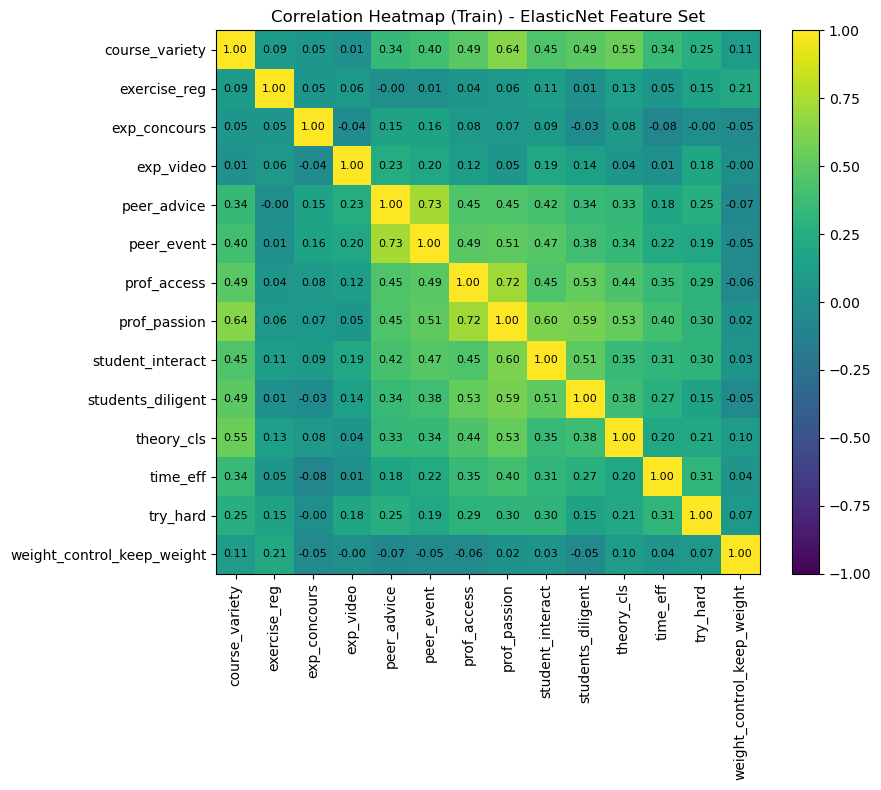

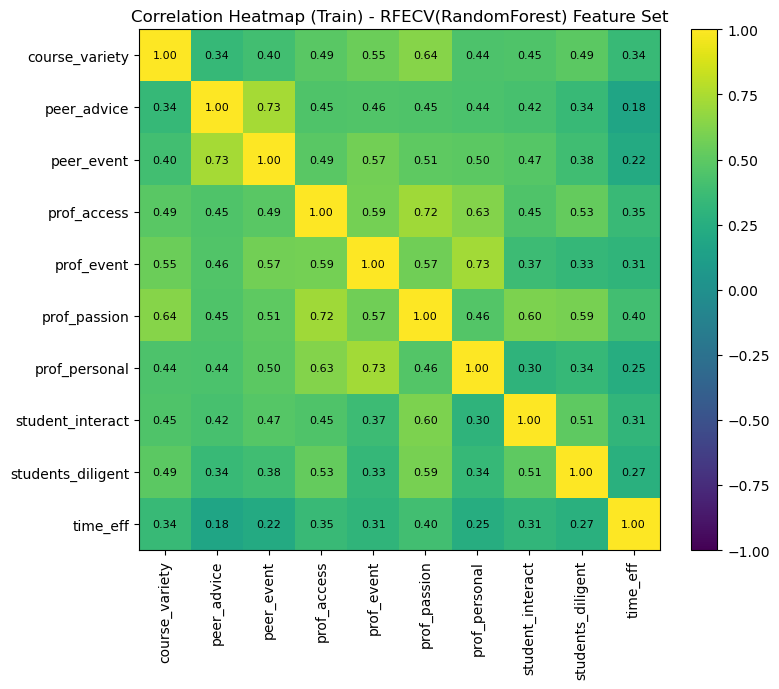

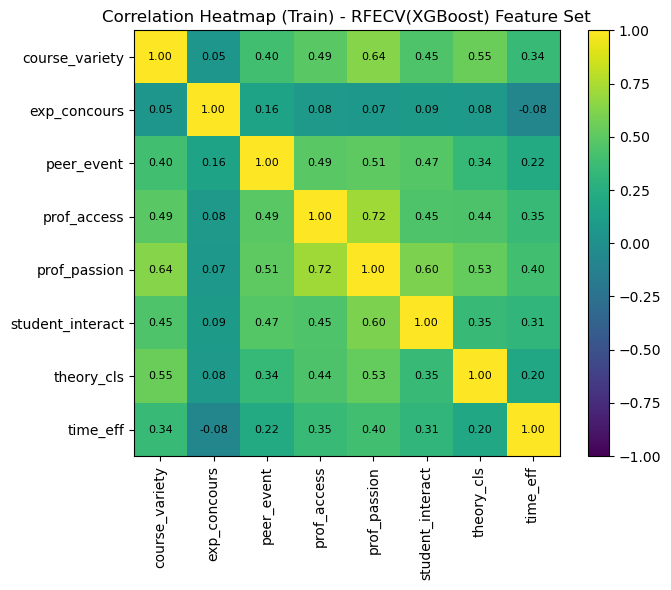

In [6]:
# ======================================
# ✅ (추가) 변수셋별 상관관계 Heatmap 3개 (Train만 사용)
# - ElasticNet / RFECV(RF) / RFECV(XGB)
# ======================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -------------------------
# 0) 안전 체크
# -------------------------
if "X_train" not in globals():
    raise RuntimeError("X_train이 없습니다. 2번 코드에서 split 후 생성된 X_train을 먼저 만든 다음 실행하세요.")

for vname in ["vars_enet", "vars_rfecv_rf", "vars_rfecv_xgb"]:
    if vname not in globals():
        raise RuntimeError(f"{vname} 리스트가 없습니다. (교집합 변수 리스트) 먼저 정의하세요.")

# -------------------------
# 1) Heatmap 그리는 함수
# -------------------------
def plot_corr_heatmap(X_df, title="", figsize=(8, 6), annot=True, vmin=-1, vmax=1):
    """
    X_df: 변수셋 데이터프레임
    annot: 숫자 표시 여부(변수 수 많으면 False 추천)
    """
    corr = X_df.corr(method="pearson")

    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(corr.values, vmin=vmin, vmax=vmax)

    # 축 라벨
    ax.set_xticks(range(corr.shape[1]))
    ax.set_yticks(range(corr.shape[0]))
    ax.set_xticklabels(corr.columns, rotation=90)
    ax.set_yticklabels(corr.index)

    ax.set_title(title)

    # 컬러바
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    # 숫자 표기(옵션)
    if annot:
        for i in range(corr.shape[0]):
            for j in range(corr.shape[1]):
                ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha="center", va="center", fontsize=8)

    plt.tight_layout()
    plt.show()

# -------------------------
# 2) 변수셋별 Heatmap 1장씩 (총 3장)
# -------------------------
X_enet = X_train[vars_enet].copy()
X_rfecv_rf = X_train[vars_rfecv_rf].copy()
X_rfecv_xgb = X_train[vars_rfecv_xgb].copy()

# 변수 개수가 많아서 숫자(annot)가 너무 빽빽하면 annot=False로 바꿔도 됨
plot_corr_heatmap(
    X_enet,
    title="Correlation Heatmap (Train) - ElasticNet Feature Set",
    figsize=(10, 8),
    annot=True
)

plot_corr_heatmap(
    X_rfecv_rf,
    title="Correlation Heatmap (Train) - RFECV(RandomForest) Feature Set",
    figsize=(9, 7),
    annot=True
)

plot_corr_heatmap(
    X_rfecv_xgb,
    title="Correlation Heatmap (Train) - RFECV(XGBoost) Feature Set",
    figsize=(8, 6),
    annot=True
)


# 3. RFECV_RF, ENET, RFECV_XGB 선택변수 기반 모델링 

In [7]:
# ======================================
# ✅ 3번 코드(최종): Repeated Hold-out (6:2:2) 30회 반복
# - 목표: 저만족(0) 분류 최적 모델 찾기 + 전체 성능도 같이 고려
# - 각 반복(rep)에서:
#   1) 6:2:2 split
#   2) Train 내부 5-fold CV 성능(CV_f1, CV_roc_auc) 계산 (참고용)
#   3) Val 성능으로 "최적 조합(변수셋+모델)" 선택
#      (기본: Val_recall_0 → Val_f1_0 → Val_balanced_acc → Val_roc_auc)
#   4) 선택된 조합을 Test에 적용해 성능 기록
# - 마지막에:
#   A) 12개 조합(3변수셋×4모델)별 Val/Test 평균±표준편차
#   B) 반복 30회 동안 "최적 선택"된 빈도(몇 번 1등 했는지)
# ======================================

import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    balanced_accuracy_score, accuracy_score
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) df / X_all / y_all 준비 (1번코드 실행 전제)
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")

target_col = "sat_group"
if target_col not in df.columns:
    raise RuntimeError("sat_group이 없습니다. 1번 코드에서 sat_group 생성 후 실행하세요.")

y_all = df[target_col].copy()

# (누수 방지) 타깃 생성에 쓰인 컬럼 제거
drop_target_related = ["sat", "sat_group", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_all = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()

# -------------------------
# 1) ✅ 2번코드 결과: 교집합 변수 리스트(여기에 너 결과를 그대로 넣기)
# -------------------------
# ※ 아래 3개 리스트는 "2번코드 출력 교집합 변수"로 교체해야 함

# (예시) 너가 이미 갖고 있는 리스트를 그대로 쓰면 됨
# vars_enet = [...]
# vars_rfecv_rf = [...]
# vars_rfecv_xgb = [...]

# 여기서 vars_*가 없으면 에러 발생하게 해둠
for vname in ["vars_enet", "vars_rfecv_rf", "vars_rfecv_xgb"]:
    if vname not in globals():
        raise RuntimeError(f"{vname} 변수가 없습니다. 2번코드 결과(교집합 변수 리스트)를 먼저 준비하세요.")

feature_sets = {
    "ElasticNet": vars_enet,
    "RFECV(RF)": vars_rfecv_rf,
    "RFECV(XGB)": vars_rfecv_xgb
}

# 변수 존재 체크
for fs_name, cols in feature_sets.items():
    missing = [c for c in cols if c not in X_all.columns]
    if missing:
        raise RuntimeError(f"[{fs_name}] 변수 중 df에 없는 컬럼이 있습니다: {missing}")

# -------------------------
# 2) 모델 정의 (스케일링: LogisticRegression만 적용)
# -------------------------
def get_models(rs):
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=rs))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=rs),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=rs, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            random_state=rs,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1
        )
    }

# -------------------------
# 3) ROC-AUC 점수(prob) 추출 함수
# -------------------------
def get_score(m, X):
    try:
        return m.predict_proba(X)[:, 1]
    except Exception:
        try:
            return m.decision_function(X)
        except Exception:
            return None

# -------------------------
# 4) 1회 반복(rep)에서 12개 조합 평가 함수
# -------------------------
def evaluate_all_combos_one_rep(X_train, y_train, X_val, y_val, X_test, y_test, rs):
    """
    rep 1회에 대해:
    - 각 변수셋×모델 조합의
      * Train 내부 5-fold CV (f1, roc_auc)
      * Val 지표(저만족0 + 전체성능)
      * Test 지표(저만족0 + 전체성능)
    를 모두 반환
    """
    models = get_models(rs)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=rs)
    scoring = {"f1": "f1", "roc_auc": "roc_auc"}  # (기본) 1 기준

    rows = []

    for fs_name, cols in feature_sets.items():
        X_tr = X_train[cols].copy()
        X_va = X_val[cols].copy()
        X_te = X_test[cols].copy()

        for model_name, model in models.items():
            # (A) Train 내부 5-fold CV (참고용: 안정성)
            cv_res = cross_validate(
                model, X_tr, y_train,
                cv=cv, scoring=scoring, n_jobs=-1, error_score=np.nan
            )
            cv_f1_mean = float(np.nanmean(cv_res["test_f1"]))
            cv_f1_std  = float(np.nanstd(cv_res["test_f1"]))
            cv_auc_mean = float(np.nanmean(cv_res["test_roc_auc"]))
            cv_auc_std  = float(np.nanstd(cv_res["test_roc_auc"]))

            # (B) Train fit
            fitted = model.fit(X_tr, y_train)

            # (C) Validation
            val_pred = fitted.predict(X_va)
            val_score = get_score(fitted, X_va)
            val_auc = roc_auc_score(y_val, val_score) if val_score is not None else np.nan

            # 저만족(0) 지표
            val_recall_0 = recall_score(y_val, val_pred, pos_label=0)
            val_precision_0 = precision_score(y_val, val_pred, pos_label=0, zero_division=0)
            val_f1_0 = f1_score(y_val, val_pred, pos_label=0)

            # 전체 성능 지표
            val_macro_f1 = f1_score(y_val, val_pred, average="macro")
            val_weighted_f1 = f1_score(y_val, val_pred, average="weighted")
            val_bal_acc = balanced_accuracy_score(y_val, val_pred)
            val_acc = accuracy_score(y_val, val_pred)

            # (D) Test
            test_pred = fitted.predict(X_te)
            test_score = get_score(fitted, X_te)
            test_auc = roc_auc_score(y_test, test_score) if test_score is not None else np.nan

            test_recall_0 = recall_score(y_test, test_pred, pos_label=0)
            test_precision_0 = precision_score(y_test, test_pred, pos_label=0, zero_division=0)
            test_f1_0 = f1_score(y_test, test_pred, pos_label=0)

            test_macro_f1 = f1_score(y_test, test_pred, average="macro")
            test_weighted_f1 = f1_score(y_test, test_pred, average="weighted")
            test_bal_acc = balanced_accuracy_score(y_test, test_pred)
            test_acc = accuracy_score(y_test, test_pred)

            rows.append({
                "rep": rs,  # 어떤 반복(seed)인지 표시

                "변수셋": fs_name,
                "모델": model_name,

                # Train CV(참고)
                "CV_f1_mean": cv_f1_mean,
                "CV_f1_std": cv_f1_std,
                "CV_roc_auc_mean": cv_auc_mean,
                "CV_roc_auc_std": cv_auc_std,

                # Val (선택 기준 + 전체 지표)
                "Val_recall_0": val_recall_0,
                "Val_precision_0": val_precision_0,
                "Val_f1_0": val_f1_0,
                "Val_roc_auc": val_auc,
                "Val_macro_f1": val_macro_f1,
                "Val_weighted_f1": val_weighted_f1,
                "Val_balanced_acc": val_bal_acc,
                "Val_accuracy": val_acc,

                # Test (최종 보고용)
                "Test_recall_0": test_recall_0,
                "Test_precision_0": test_precision_0,
                "Test_f1_0": test_f1_0,
                "Test_roc_auc": test_auc,
                "Test_macro_f1": test_macro_f1,
                "Test_weighted_f1": test_weighted_f1,
                "Test_balanced_acc": test_bal_acc,
                "Test_accuracy": test_acc,
            })

    return pd.DataFrame(rows)

# -------------------------
# 5) ✅ 반복 홀드아웃 실행
# -------------------------
N_REP = 30  # 반복 횟수 (원하면 50도 가능)
all_rep_results = []
best_pick_rows = []  # rep마다 "Val 기준 1등"이 누군지 기록

for k in range(N_REP):
    rs = RANDOM_STATE + k  # 반복마다 다른 seed

    # (1) 6:2:2 split
    X_train_val, X_test, y_train_val, y_test = train_test_split(
        X_all, y_all, test_size=0.2, stratify=y_all, random_state=rs
    )
    X_train, X_val, y_train, y_val = train_test_split(
        X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=rs
    )

    # (2) 12개 조합 평가
    rep_df = evaluate_all_combos_one_rep(
        X_train, y_train, X_val, y_val, X_test, y_test, rs
    )
    all_rep_results.append(rep_df)

    # (3) ✅ rep 내부에서 "Val 기준 최적" 1개 선택
    #     저만족(0) 우선 + 전체도 반영
    rep_sorted = rep_df.sort_values(
        by=["Val_recall_0", "Val_f1_0", "Val_balanced_acc", "Val_roc_auc"],
        ascending=[False, False, False, False]
    ).reset_index(drop=True)

    best = rep_sorted.iloc[0].to_dict()
    best_pick_rows.append(best)

# 전체 반복 결과 합치기
res_rep_all = pd.concat(all_rep_results, ignore_index=True)
best_picks = pd.DataFrame(best_pick_rows)

print("✅ 반복 홀드아웃 완료")
print("전체 기록 row 수:", res_rep_all.shape[0], " (예상:", N_REP * 12, ")")
print("best_picks row 수:", best_picks.shape[0], " (예상:", N_REP, ")")

# ============================================================
# ✅ (정리 버전) 필수 지표만으로 결과 출력 깔끔하게
# - res_rep_all, best_picks가 이미 만들어진 상태에서 실행
# ============================================================

import numpy as np
import pandas as pd

# -------------------------
# 0) 논문/보고서용 "핵심 지표"만 선택
# -------------------------
# 너의 선택 기준(저만족=0 우선 + 전체 성능 고려)에 딱 맞게 최소화
CORE_METRICS = [
    # Val (모델 선택에 실제로 쓴 지표들)
    "Val_recall_0",
    "Val_f1_0",
    "Val_balanced_acc",
    "Val_roc_auc",
    # Test (최종 보고용 핵심)
    "Test_recall_0",
    "Test_f1_0",
    "Test_balanced_acc",
    "Test_roc_auc",
]

# (선택) Train CV는 본문표에서 빼고 싶으면 False로
INCLUDE_CV = False
if INCLUDE_CV:
    CORE_METRICS = ["CV_f1_mean", "CV_roc_auc_mean"] + CORE_METRICS

# -------------------------
# 1) 12개 조합별 평균±표준편차 요약표 (핵심 지표만)
# -------------------------
summary_core = (
    res_rep_all
    .groupby(["변수셋", "모델"])[CORE_METRICS]
    .agg(["mean", "std"])
)

# 컬럼 평탄화
summary_core.columns = [f"{m}_{stat}" for m, stat in summary_core.columns]
summary_core = summary_core.reset_index()

# Val 기준(선택기준과 동일하게) 정렬
summary_core = summary_core.sort_values(
    by=["Val_recall_0_mean", "Val_f1_0_mean", "Val_balanced_acc_mean", "Val_roc_auc_mean"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

print("\n✅ [요약표] 12개 조합 성능(30회 평균±표준편차) - 핵심 지표만")
display(summary_core)

# -------------------------
# 2) 반복 30회 동안 Val 1등 선택 빈도(Top만 보고 싶으면 head 사용)
# -------------------------
N_REP = best_picks.shape[0]

pick_count = (
    best_picks
    .groupby(["변수셋", "모델"])
    .size()
    .reset_index(name="best_selected_count")
    .sort_values("best_selected_count", ascending=False)
    .reset_index(drop=True)
)
pick_count["best_selected_ratio"] = pick_count["best_selected_count"] / N_REP

print("\n✅ [빈도표] Val 기준 1등으로 선택된 횟수")
display(pick_count)

# -------------------------
# 3) 최종 랭킹(빈도 + Test 핵심 성능) + TopN만 출력
# -------------------------
final_rank_core = summary_core.merge(pick_count, on=["변수셋", "모델"], how="left")
final_rank_core["best_selected_count"] = final_rank_core["best_selected_count"].fillna(0).astype(int)
final_rank_core["best_selected_ratio"] = final_rank_core["best_selected_ratio"].fillna(0.0)

# "일관되게 뽑히는지(빈도)" + "테스트에서 실제 성능"
final_rank_core = final_rank_core.sort_values(
    by=["best_selected_count", "Test_recall_0_mean", "Test_balanced_acc_mean", "Test_roc_auc_mean"],
    ascending=[False, False, False, False]
).reset_index(drop=True)

TOP_N = 5  # 필요하면 3으로 줄이기
cols_to_show = [
    "변수셋", "모델",
    "best_selected_count", "best_selected_ratio",
    "Val_recall_0_mean", "Val_f1_0_mean", "Val_balanced_acc_mean", "Val_roc_auc_mean",
    "Test_recall_0_mean", "Test_f1_0_mean", "Test_balanced_acc_mean", "Test_roc_auc_mean"
]

print(f"\n✅ [최종 랭킹] Top {TOP_N} (빈도 + Test 핵심 성능)")
display(final_rank_core[cols_to_show].head(TOP_N))

# -------------------------
# 4) 최종 1순위 한 줄 요약
# -------------------------
top1 = final_rank_core.iloc[0]
print("\n🏁 최종 1순위 후보(반복 기준)")
print(f"- 변수셋: {top1['변수셋']} | 모델: {top1['모델']}")
print(f"- 선택 빈도: {top1['best_selected_count']}/{N_REP} ({top1['best_selected_ratio']:.1%})")
print(f"- Test_recall_0_mean: {top1['Test_recall_0_mean']:.3f} ± {top1['Test_recall_0_std']:.3f}")
print(f"- Test_balanced_acc_mean: {top1['Test_balanced_acc_mean']:.3f} ± {top1['Test_balanced_acc_std']:.3f}")
print(f"- Test_roc_auc_mean: {top1['Test_roc_auc_mean']:.3f} ± {top1['Test_roc_auc_std']:.3f}")


✅ 반복 홀드아웃 완료
전체 기록 row 수: 360  (예상: 360 )
best_picks row 수: 30  (예상: 30 )

✅ [요약표] 12개 조합 성능(30회 평균±표준편차) - 핵심 지표만


,변수셋,모델,Val_recall_0_mean,Val_recall_0_std,Val_f1_0_mean,Val_f1_0_std,Val_balanced_acc_mean,Val_balanced_acc_std,Val_roc_auc_mean,Val_roc_auc_std,Test_recall_0_mean,Test_recall_0_std,Test_f1_0_mean,Test_f1_0_std,Test_balanced_acc_mean,Test_balanced_acc_std,Test_roc_auc_mean,Test_roc_auc_std
0,ElasticNet,LogisticRegression,0.765476,0.097327,0.773142,0.057046,0.813746,0.045851,0.906645,0.034556,0.757143,0.077000,0.765370,0.054859,0.806091,0.045061,0.895847,0.036934
1,RFECV(XGB),LogisticRegression,0.747619,0.102284,0.763454,0.071450,0.806368,0.056769,0.893425,0.045874,0.751190,0.080399,0.769521,0.055722,0.810479,0.045663,0.886766,0.044935
2,RFECV(RF),LogisticRegression,0.746429,0.098524,0.765473,0.074501,0.807710,0.059847,0.889826,0.046982,0.745238,0.073692,0.761537,0.061335,0.803627,0.050329,0.880994,0.042579
3,ElasticNet,XGBoost,0.726190,0.097620,0.721380,0.054975,0.770847,0.045114,0.861573,0.039788,0.715476,0.071110,0.712820,0.050339,0.762777,0.041804,0.853668,0.039638
4,ElasticNet,RandomForest,0.717857,0.101601,0.740545,0.061838,0.788774,0.048462,0.884607,0.038303,0.722619,0.073062,0.737338,0.060795,0.783790,0.050084,0.879513,0.040327
5,RFECV(XGB),RandomForest,0.710714,0.119136,0.729580,0.080367,0.780939,0.060819,0.877229,0.039237,0.733333,0.070644,0.749992,0.058922,0.793798,0.048300,0.876855,0.040956
6,RFECV(RF),RandomForest,0.696429,0.099590,0.710495,0.061462,0.764106,0.048207,0.849322,0.047080,0.705952,0.082665,0.715866,0.063110,0.766930,0.050459,0.851204,0.048728
7,RFECV(XGB),XGBoost,0.688095,0.108543,0.702170,0.066393,0.758001,0.050036,0.847854,0.040377,0.717857,0.094421,0.722233,0.072010,0.771332,0.058713,0.849792,0.043274
8,RFECV(XGB),DecisionTree,0.678571,0.102313,0.671087,0.062798,0.729208,0.049075,0.726370,0.048645,0.679762,0.106312,0.666590,0.084749,0.723602,0.069121,0.722688,0.070703
9,RFECV(RF),XGBoost,0.670238,0.118519,0.667280,0.070636,0.728530,0.053351,0.825706,0.043623,0.689286,0.077993,0.691243,0.055910,0.746193,0.045088,0.821027,0.042784



✅ [빈도표] Val 기준 1등으로 선택된 횟수


,변수셋,모델,best_selected_count,best_selected_ratio
0,ElasticNet,LogisticRegression,10,0.333333
1,RFECV(XGB),LogisticRegression,6,0.200000
2,RFECV(RF),LogisticRegression,5,0.166667
3,ElasticNet,XGBoost,4,0.133333
4,ElasticNet,DecisionTree,3,0.100000
5,RFECV(RF),RandomForest,1,0.033333
6,RFECV(RF),XGBoost,1,0.033333



✅ [최종 랭킹] Top 5 (빈도 + Test 핵심 성능)


,변수셋,모델,best_selected_count,best_selected_ratio,Val_recall_0_mean,Val_f1_0_mean,Val_balanced_acc_mean,Val_roc_auc_mean,Test_recall_0_mean,Test_f1_0_mean,Test_balanced_acc_mean,Test_roc_auc_mean
0,ElasticNet,LogisticRegression,10,0.333333,0.765476,0.773142,0.813746,0.906645,0.757143,0.765370,0.806091,0.895847
1,RFECV(XGB),LogisticRegression,6,0.200000,0.747619,0.763454,0.806368,0.893425,0.751190,0.769521,0.810479,0.886766
2,RFECV(RF),LogisticRegression,5,0.166667,0.746429,0.765473,0.807710,0.889826,0.745238,0.761537,0.803627,0.880994
3,ElasticNet,XGBoost,4,0.133333,0.726190,0.721380,0.770847,0.861573,0.715476,0.712820,0.762777,0.853668
4,ElasticNet,DecisionTree,3,0.100000,0.657143,0.649194,0.711905,0.711905,0.676190,0.661470,0.720266,0.720266



🏁 최종 1순위 후보(반복 기준)
- 변수셋: ElasticNet | 모델: LogisticRegression
- 선택 빈도: 10/30 (33.3%)
- Test_recall_0_mean: 0.757 ± 0.077
- Test_balanced_acc_mean: 0.806 ± 0.045
- Test_roc_auc_mean: 0.896 ± 0.037


In [12]:
# ======================================
# ✅ 3번 코드: 12개 모델링 (3 변수셋 × 4 모델)
# - 변수셋: RFECV(RF), ElasticNet, RFECV(XGB) 의 5fold 교집합 변수
# - 모델: LogReg / DT / RF / XGB
# - 분할: 6:2:2 (train/val/test)
# - 모델선정: Val_recall_0 → Val_f1_0 → Val_roc_auc (저만족=0 우선)
# - 스케일링: LogisticRegression만 Pipeline에 StandardScaler 적용
# ======================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    f1_score, precision_score, recall_score, roc_auc_score,
    balanced_accuracy_score, accuracy_score
)
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) df / X / y 준비
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")

target_col = "sat_group"
if target_col not in df.columns:
    raise RuntimeError("sat_group이 없습니다. 1번 코드에서 sat_group 생성 후 실행하세요.")

y_all = df[target_col].copy()

# 타깃 생성에 사용된 변수 제거(누수 방지)
drop_target_related = ["sat", "sat_group", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_all = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()

# -------------------------
# 1) ✅ 6:2:2 분할 (Stratify 유지)
# -------------------------
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)
print(f"✅ Split | Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# -------------------------
# 2) ✅ 2번 코드 결과(교집합 변수 리스트) 입력
# -------------------------
vars_enet = [
    'course_variety', 'exercise_reg', 'exp_concours', 'exp_video', 'peer_advice',
    'peer_event', 'prof_access', 'prof_passion', 'student_interact', 'students_diligent',
    'theory_cls', 'time_eff', 'try_hard', 'weight_control_keep_weight'
]

vars_rfecv_rf = [
    'course_variety', 'peer_advice', 'peer_event', 'prof_access', 'prof_event',
    'prof_passion', 'prof_personal', 'student_interact', 'students_diligent', 'time_eff'
]

vars_rfecv_xgb = [
    'course_variety', 'exp_concours', 'peer_event', 'prof_access',
    'prof_passion', 'student_interact', 'theory_cls', 'time_eff'
]

feature_sets = {
    "ElasticNet": vars_enet,
    "RFECV(RF)": vars_rfecv_rf,
    "RFECV(XGB)": vars_rfecv_xgb
}

# 변수 존재 체크
for fs_name, cols in feature_sets.items():
    missing = [c for c in cols if c not in X_all.columns]
    if missing:
        raise RuntimeError(f"[{fs_name}] 변수 중 df에 없는 컬럼이 있습니다: {missing}")

# -------------------------
# 3) 모델 정의 (스케일링: LR만 적용)
# -------------------------
def get_models():
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1
        )
    }

# -------------------------
# 4) 점수(ROC-AUC) 추출 함수
# -------------------------
def get_score(m, X):
    try:
        return m.predict_proba(X)[:, 1]
    except Exception:
        try:
            return m.decision_function(X)
        except Exception:
            return None

# -------------------------
# 5) 평가 함수: CV(Train 내부) + Val/Test 지표
# -------------------------
def evaluate_one_feature_set(fs_name, cols, X_train, y_train, X_val, y_val, X_test, y_test, models):
    X_tr = X_train[cols].copy()
    X_va = X_val[cols].copy()
    X_te = X_test[cols].copy()

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
    scoring = {"f1": "f1", "roc_auc": "roc_auc"}  # 전체 기준(1)

    rows = []
    for model_name, model in models.items():
        # (A) Train 내부 CV (참고)
        cv_res = cross_validate(model, X_tr, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score=np.nan)
        cv_f1_mean = float(np.nanmean(cv_res["test_f1"]))
        cv_f1_std  = float(np.nanstd(cv_res["test_f1"]))
        cv_auc_mean = float(np.nanmean(cv_res["test_roc_auc"]))
        cv_auc_std  = float(np.nanstd(cv_res["test_roc_auc"]))

        # (B) Train fit
        fitted = model.fit(X_tr, y_train)

        # (C) Validation
        val_pred = fitted.predict(X_va)
        val_score = get_score(fitted, X_va)
        val_auc = roc_auc_score(y_val, val_score) if val_score is not None else np.nan

        # 저만족(0) 중심 지표
        val_recall_0 = recall_score(y_val, val_pred, pos_label=0)
        val_precision_0 = precision_score(y_val, val_pred, pos_label=0, zero_division=0)
        val_f1_0 = f1_score(y_val, val_pred, pos_label=0)

        # 전체 성능 참고 지표
        val_macro_f1 = f1_score(y_val, val_pred, average="macro")
        val_weighted_f1 = f1_score(y_val, val_pred, average="weighted")
        val_bal_acc = balanced_accuracy_score(y_val, val_pred)
        val_acc = accuracy_score(y_val, val_pred)

        # (D) Test (최종 보고용)
        test_pred = fitted.predict(X_te)
        test_score = get_score(fitted, X_te)
        test_auc = roc_auc_score(y_test, test_score) if test_score is not None else np.nan

        test_recall_0 = recall_score(y_test, test_pred, pos_label=0)
        test_precision_0 = precision_score(y_test, test_pred, pos_label=0, zero_division=0)
        test_f1_0 = f1_score(y_test, test_pred, pos_label=0)

        test_macro_f1 = f1_score(y_test, test_pred, average="macro")
        test_weighted_f1 = f1_score(y_test, test_pred, average="weighted")
        test_bal_acc = balanced_accuracy_score(y_test, test_pred)
        test_acc = accuracy_score(y_test, test_pred)

        rows.append({
            "변수셋": fs_name,
            "모델": model_name,

            # Train CV (전체 성능 비교용 참고)
            "CV_f1_mean": cv_f1_mean,
            "CV_f1_std": cv_f1_std,
            "CV_roc_auc_mean": cv_auc_mean,
            "CV_roc_auc_std": cv_auc_std,

            # Val (모델 선택 기준: 저만족 0)
            "Val_recall_0": val_recall_0,
            "Val_precision_0": val_precision_0,
            "Val_f1_0": val_f1_0,
            "Val_roc_auc": val_auc,

            # Val 참고
            "Val_macro_f1": val_macro_f1,
            "Val_weighted_f1": val_weighted_f1,
            "Val_balanced_acc": val_bal_acc,
            "Val_accuracy": val_acc,

            # Test (최종 보고용)
            "Test_recall_0": test_recall_0,
            "Test_precision_0": test_precision_0,
            "Test_f1_0": test_f1_0,
            "Test_roc_auc": test_auc,

            # Test 참고
            "Test_macro_f1": test_macro_f1,
            "Test_weighted_f1": test_weighted_f1,
            "Test_balanced_acc": test_bal_acc,
            "Test_accuracy": test_acc,
        })

    return pd.DataFrame(rows)

# -------------------------
# 6) 실행: 3 변수셋 × 4 모델 = 12개
# -------------------------
models = get_models()

all_results = []
for fs_name, cols in feature_sets.items():
    df_res = evaluate_one_feature_set(
        fs_name, cols, X_train, y_train, X_val, y_val, X_test, y_test, models
    )
    all_results.append(df_res)

res_12 = pd.concat(all_results, ignore_index=True)

# ✅ 모델 선정 정렬(Val 기준): 저만족(0) 우선
res_12_sorted = res_12.sort_values(
    by=["Val_recall_0", "Val_f1_0", "Val_roc_auc"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n✅ (총 12개) Val 기준 성능 비교표 (저만족=0 우선 정렬)")
display(res_12_sorted)

best = res_12_sorted.iloc[0]
print("\n✅ Val 기준 최적 조합(변수셋+모델)")
print(f"- 변수셋: {best['변수셋']}")
print(f"- 모델: {best['모델']}")
print(f"- Val_recall_0: {best['Val_recall_0']:.3f} | Val_f1_0: {best['Val_f1_0']:.3f} | Val_roc_auc: {best['Val_roc_auc']:.3f}")
print(f"- Test_recall_0: {best['Test_recall_0']:.3f} | Test_f1_0: {best['Test_f1_0']:.3f} | Test_roc_auc: {best['Test_roc_auc']:.3f}")


✅ Split | Train: (213, 171), Val: (71, 171), Test: (71, 171)

✅ (총 12개) Val 기준 성능 비교표 (저만족=0 우선 정렬)


,변수셋,모델,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_recall_0,Val_precision_0,Val_f1_0,Val_roc_auc,...,Val_balanced_acc,Val_accuracy,Test_recall_0,Test_precision_0,Test_f1_0,Test_roc_auc,Test_macro_f1,Test_weighted_f1,Test_balanced_acc,Test_accuracy
0,RFECV(RF),XGBoost,0.810732,0.022047,0.831541,0.047528,0.892857,0.735294,0.806452,0.868771,...,0.841777,0.830986,0.714286,0.625000,0.666667,0.809801,0.711382,0.720829,0.717608,0.718310
1,RFECV(XGB),XGBoost,0.805777,0.021735,0.858999,0.031907,0.821429,0.766667,0.793103,0.847176,...,0.829319,0.830986,0.857143,0.685714,0.761905,0.839286,0.786016,0.791110,0.800664,0.788732
2,ElasticNet,RandomForest,0.847172,0.035204,0.910866,0.034371,0.785714,0.758621,0.771930,0.872093,...,0.811462,0.816901,0.821429,0.638889,0.718750,0.874169,0.743990,0.749323,0.759551,0.746479
3,RFECV(RF),LogisticRegression,0.867672,0.011867,0.897721,0.023875,0.785714,0.758621,0.771930,0.867110,...,0.811462,0.816901,0.750000,0.656250,0.700000,0.856312,0.740244,0.748746,0.747093,0.746479
4,RFECV(XGB),RandomForest,0.850044,0.012863,0.898128,0.029495,0.785714,0.733333,0.758621,0.857558,...,0.799834,0.802817,0.821429,0.676471,0.741935,0.850083,0.770968,0.777101,0.782807,0.774648
5,ElasticNet,LogisticRegression,0.877722,0.015382,0.917253,0.013808,0.785714,0.709677,0.745763,0.880399,...,0.788206,0.788732,0.821429,0.621622,0.707692,0.853821,0.730470,0.735282,0.747924,0.732394
6,RFECV(XGB),LogisticRegression,0.866089,0.030546,0.914138,0.022279,0.750000,0.807692,0.777778,0.879568,...,0.816860,0.830986,0.750000,0.677419,0.711864,0.829319,0.753523,0.762324,0.758721,0.760563
7,RFECV(RF),RandomForest,0.807957,0.033218,0.849135,0.054441,0.750000,0.724138,0.736842,0.854651,...,0.781977,0.788732,0.785714,0.647059,0.709677,0.854651,0.742339,0.749239,0.753322,0.746479
8,ElasticNet,XGBoost,0.840917,0.032541,0.886089,0.019765,0.750000,0.724138,0.736842,0.833056,...,0.781977,0.788732,0.821429,0.638889,0.718750,0.869601,0.743990,0.749323,0.759551,0.746479
9,ElasticNet,DecisionTree,0.793646,0.028455,0.727785,0.016126,0.750000,0.617647,0.677419,0.723837,...,0.723837,0.718310,0.857143,0.666667,0.750000,0.789037,0.772436,0.777176,0.789037,0.774648



✅ Val 기준 최적 조합(변수셋+모델)
- 변수셋: RFECV(RF)
- 모델: XGBoost
- Val_recall_0: 0.893 | Val_f1_0: 0.806 | Val_roc_auc: 0.869
- Test_recall_0: 0.714 | Test_f1_0: 0.667 | Test_roc_auc: 0.810


In [13]:
# 전체 성능 기준(Val)으로 정렬: balanced_acc → macro_f1 → roc_auc
res_overall = res_12.sort_values(
    by=["Val_balanced_acc", "Val_macro_f1", "Val_roc_auc"],
    ascending=[False, False, False]
).reset_index(drop=True)

display(res_overall[["변수셋","모델",
                     "Val_balanced_acc","Val_macro_f1","Val_roc_auc","Val_accuracy",
                     "Test_balanced_acc","Test_macro_f1","Test_roc_auc","Test_accuracy"]].head(12))


,변수셋,모델,Val_balanced_acc,Val_macro_f1,Val_roc_auc,Val_accuracy,Test_balanced_acc,Test_macro_f1,Test_roc_auc,Test_accuracy
0,RFECV(RF),XGBoost,0.841777,0.828226,0.868771,0.830986,0.717608,0.711382,0.809801,0.718310
1,RFECV(XGB),XGBoost,0.829319,0.825123,0.847176,0.830986,0.800664,0.786016,0.839286,0.788732
2,RFECV(XGB),LogisticRegression,0.816860,0.820707,0.879568,0.830986,0.758721,0.753523,0.829319,0.760563
3,ElasticNet,RandomForest,0.811462,0.809494,0.872093,0.816901,0.759551,0.743990,0.874169,0.746479
4,RFECV(RF),LogisticRegression,0.811462,0.809494,0.867110,0.816901,0.747093,0.740244,0.856312,0.746479
5,RFECV(XGB),RandomForest,0.799834,0.795977,0.857558,0.802817,0.782807,0.770968,0.850083,0.774648
6,ElasticNet,LogisticRegression,0.788206,0.782520,0.880399,0.788732,0.747924,0.730470,0.853821,0.732394
7,RFECV(RF),RandomForest,0.781977,0.780186,0.854651,0.788732,0.753322,0.742339,0.854651,0.746479
8,ElasticNet,XGBoost,0.781977,0.780186,0.833056,0.788732,0.759551,0.743990,0.869601,0.746479
9,RFECV(RF),DecisionTree,0.729236,0.724525,0.727575,0.732394,0.747924,0.730470,0.785714,0.732394


In [ ]:
# ======================================
# ✅ 2번 코드 (최종 정석: 6:2:2 split + Train 내부 5-fold 변수선택)
# - 먼저 train/val/test = 6:2:2 분할 (누수 방지)
# - 변수선택 비교는 train에서만 5-fold로 수행
# - 방법별:
#   * fold별 선택변수 저장
#   * 5fold 교집합 변수 산출
#   * 안정성: Jaccard(폴드간 평균 pairwise)
#   * 성능: CV F1 / CV ROC-AUC (5fold 평균±표준편차)
# - 결과표로 비교 후, 상위 2개 방법의 교집합 변수를 3번 코드에서 모델링에 사용
# ======================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import RFECV
from sklearn.linear_model import LogisticRegression, LogisticRegressionCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import f1_score, roc_auc_score
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) df 체크 & X, y 구성
# -------------------------
if "df" not in globals():
    raise RuntimeError("df가 없습니다. 1번 코드(전처리)부터 실행하세요.")

target_col = "sat_group"
if target_col not in df.columns:
    raise RuntimeError("sat_group이 없습니다. 1번 코드에서 sat_group 생성 후 실행하세요.")

y_all = df[target_col].copy()

# 타깃 생성에 사용된 변수 제거(누수 방지)
drop_target_related = ["sat", "sat_group", "univ_proud", "univ_belong", "major_proud", "major_belong"]
X_all = df.drop(columns=[c for c in drop_target_related if c in df.columns]).copy()

# -------------------------
# 1) ✅ 6:2:2 분할 (Stratify 유지)
# -------------------------
# (1) train+val(80) vs test(20)
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=RANDOM_STATE
)

# (2) train(60) vs val(20)  -> train_val의 25%가 val
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=0.25, stratify=y_train_val, random_state=RANDOM_STATE
)

print(f"✅ Split 완료 | Train: {X_train.shape}, Val: {X_val.shape}, Test: {X_test.shape}")

# -------------------------
# 2) Jaccard 평균(pairwise)
# -------------------------
def mean_pairwise_jaccard(list_of_sets):
    if len(list_of_sets) < 2:
        return np.nan
    vals = []
    for i in range(len(list_of_sets)):
        for j in range(i + 1, len(list_of_sets)):
            a, b = list_of_sets[i], list_of_sets[j]
            inter = len(a & b)
            union = len(a | b)
            vals.append(inter / union if union > 0 else 0.0)
    return float(np.mean(vals)) if vals else np.nan

# -------------------------
# 3) fold 실행 함수들 (방법별 변수선택 + fold 성능평가)
# -------------------------
def elasticnet_select_and_eval(X_tr, y_tr, X_va, y_va):
    """
    ElasticNet(LR-CV)로 변수선택 + LR로 fold 성능평가
    - 스케일링: fold train에서만 fit (Pipeline)
    - 성능: F1, ROC-AUC (표준: 1 기준 점수)
    """
    selector = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegressionCV(
            Cs=20,
            cv=5,
            penalty="elasticnet",
            solver="saga",
            l1_ratios=[0.5],
            max_iter=10000,
            n_jobs=-1,
            random_state=RANDOM_STATE
        ))
    ])
    selector.fit(X_tr, y_tr)
    coef = selector.named_steps["clf"].coef_.ravel()
    sel_cols = list(X_tr.columns[coef != 0])

    if len(sel_cols) == 0:
        return set(), np.nan, np.nan

    model = Pipeline([
        ("scaler", StandardScaler()),
        ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE))
    ])
    model.fit(X_tr[sel_cols], y_tr)

    y_pred = model.predict(X_va[sel_cols])
    f1 = f1_score(y_va, y_pred)

    try:
        y_score = model.predict_proba(X_va[sel_cols])[:, 1]
        auc = roc_auc_score(y_va, y_score)
    except Exception:
        auc = np.nan

    return set(sel_cols), f1, auc


def rfecv_select_and_eval(method, X_tr, y_tr, X_va, y_va):
    """
    RFECV로 변수선택 + 같은 모델로 fold 성능평가
    - RFECV scoring: 'f1' (기본 1 기준)
    - 성능: F1, ROC-AUC (표준: 1 기준 점수)
    """
    if method == "LR":
        base = LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE)
        selector = Pipeline([
            ("scaler", StandardScaler()),
            ("rfecv", RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1))
        ])
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=5000, solver="liblinear", random_state=RANDOM_STATE))
        ])

    elif method == "DT":
        base = DecisionTreeClassifier(random_state=RANDOM_STATE)
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        model = DecisionTreeClassifier(random_state=RANDOM_STATE)

    elif method == "RF":
        base = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        model = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)

    elif method == "XGB":
        base = XGBClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1
        )
        selector = RFECV(estimator=base, step=1, cv=5, scoring="f1", n_jobs=-1)
        model = XGBClassifier(
            n_estimators=300,
            random_state=RANDOM_STATE,
            eval_metric="logloss",
            use_label_encoder=False,
            n_jobs=-1
        )
    else:
        raise ValueError("method는 'LR','DT','RF','XGB' 중 하나여야 합니다.")

    selector.fit(X_tr, y_tr)

    if isinstance(selector, Pipeline):
        support = selector.named_steps["rfecv"].support_
    else:
        support = selector.support_

    sel_cols = list(X_tr.columns[support])
    if len(sel_cols) == 0:
        return set(), np.nan, np.nan

    model.fit(X_tr[sel_cols], y_tr)

    y_pred = model.predict(X_va[sel_cols])
    f1 = f1_score(y_va, y_pred)

    try:
        y_score = model.predict_proba(X_va[sel_cols])[:, 1]
        auc = roc_auc_score(y_va, y_score)
    except Exception:
        auc = np.nan

    return set(sel_cols), f1, auc

# -------------------------
# 4) ✅ Train 내부에서만 5-fold 실행
# -------------------------
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

methods = ["ElasticNet", "RFECV(LR)", "RFECV(DT)", "RFECV(RF)", "RFECV(XGB)"]

fold_sets = {m: [] for m in methods}
fold_f1 = {m: [] for m in methods}
fold_auc = {m: [] for m in methods}

for fold, (tr_idx, va_idx) in enumerate(cv.split(X_train, y_train), start=1):
    X_tr, X_va = X_train.iloc[tr_idx], X_train.iloc[va_idx]
    y_tr, y_va = y_train.iloc[tr_idx], y_train.iloc[va_idx]

    # ElasticNet
    sel, f1, auc = elasticnet_select_and_eval(X_tr, y_tr, X_va, y_va)
    fold_sets["ElasticNet"].append(sel)
    fold_f1["ElasticNet"].append(f1)
    fold_auc["ElasticNet"].append(auc)

    # RFECV family
    for short in ["LR", "DT", "RF", "XGB"]:
        key = f"RFECV({short})"
        sel, f1, auc = rfecv_select_and_eval(short, X_tr, y_tr, X_va, y_va)
        fold_sets[key].append(sel)
        fold_f1[key].append(f1)
        fold_auc[key].append(auc)

# -------------------------
# 5) 요약표 + 교집합 변수 출력 + 3번 코드용 변수 저장
# -------------------------
summary_rows = []
intersection_vars = {}

for m in methods:
    sets_ = fold_sets[m]
    inter = set.intersection(*sets_) if len(sets_) > 0 else set()
    intersection_vars[m] = sorted(list(inter))

    summary_rows.append({
        "방법": m,
        "안정적 변수 수(교집합)": len(inter),
        "CV_F1_mean": float(np.nanmean(fold_f1[m])),
        "CV_F1_std": float(np.nanstd(fold_f1[m])),
        "CV_ROC_AUC_mean": float(np.nanmean(fold_auc[m])),
        "CV_ROC_AUC_std": float(np.nanstd(fold_auc[m])),
        "Jaccard_mean": mean_pairwise_jaccard(sets_),
    })

fs_table = pd.DataFrame(summary_rows).sort_values(
    by=["CV_F1_mean", "CV_ROC_AUC_mean", "Jaccard_mean"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n✅ [표] 변수선택 방법 비교 (Train 내부 5-fold)")
display(fs_table)

print("\n✅ [리스트] 방법별 5-fold 교집합 변수 (Train 내부에서만 산출)")
for m in methods:
    print(f"\n--- {m} (교집합 {len(intersection_vars[m])}개) ---")
    print(intersection_vars[m])

# ✅ 3번 코드에서 쓰기 좋게: 상위 2개 방법 자동 선택
selected_fs_methods = fs_table["방법"].iloc[:2].tolist()
selected_feature_sets = {m: intersection_vars[m] for m in selected_fs_methods}

print("\n✅ [3번코드 참고] 추천 변수선택방법 TOP2:", selected_fs_methods)
for m in selected_fs_methods:
    print(f"- {m}: 교집합 변수 {len(selected_feature_sets[m])}개")

# ✅ 3번 코드에서 그대로 쓰라고 분할 데이터도 남겨둠
# X_train, X_val, X_test, y_train, y_val, y_test


✅ Split 완료 | Train: (213, 171), Val: (71, 171), Test: (71, 171)

✅ [표] 변수선택 방법 비교 (Train 내부 5-fold)


,방법,안정적 변수 수(교집합),CV_F1_mean,CV_F1_std,CV_ROC_AUC_mean,CV_ROC_AUC_std,Jaccard_mean
0,RFECV(RF),10,0.850407,0.038395,0.864889,0.069945,0.413629
1,RFECV(XGB),8,0.814143,0.051664,0.840837,0.053567,0.369871
2,ElasticNet,14,0.809383,0.040554,0.826271,0.038513,0.416336
3,RFECV(LR),1,0.777824,0.061351,0.809727,0.038604,0.114712
4,RFECV(DT),0,0.773489,0.058020,0.753822,0.071693,0.136190



✅ [리스트] 방법별 5-fold 교집합 변수 (Train 내부에서만 산출)

--- ElasticNet (교집합 14개) ---
['course_variety', 'exercise_reg', 'exp_concours', 'exp_video', 'peer_advice', 'peer_event', 'prof_access', 'prof_passion', 'student_interact', 'students_diligent', 'theory_cls', 'time_eff', 'try_hard', 'weight_control_keep_weight']

--- RFECV(LR) (교집합 1개) ---
['prof_passion']

--- RFECV(DT) (교집합 0개) ---
[]

--- RFECV(RF) (교집합 10개) ---
['course_variety', 'peer_advice', 'peer_event', 'prof_access', 'prof_event', 'prof_passion', 'prof_personal', 'student_interact', 'students_diligent', 'time_eff']

--- RFECV(XGB) (교집합 8개) ---
['course_variety', 'exp_concours', 'peer_event', 'prof_access', 'prof_passion', 'student_interact', 'theory_cls', 'time_eff']

✅ [3번코드 참고] 추천 변수선택방법 TOP2: ['RFECV(RF)', 'RFECV(XGB)']
- RFECV(RF): 교집합 변수 10개
- RFECV(XGB): 교집합 변수 8개


In [3]:
# ======================================
# ✅ 최종 모델링 (6:2:2 분할, 동일 인덱스 고정)
# RFECV_RF 교집합 변수 vs ElasticNet 교집합 변수
# 4개 모델(LogReg/DT/RF/XGB) → 총 8개 비교
# ✅ 모델선정 기준: Val_recall_0 (저만족=0 재현율)
# - 누수 방지: 스케일링은 Pipeline 내부
# - 공정 비교: 두 변수셋 동일 split 인덱스 사용
# ======================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score
)
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) 데이터/타깃 체크
# -------------------------
try:
    df
except NameError:
    raise RuntimeError("df가 없습니다. 전처리(1번째 코드)부터 실행하세요.")

target_col = "sat_group"
if target_col not in df.columns:
    raise RuntimeError("sat_group이 없습니다. sat_group 생성(1번째 코드)을 먼저 실행하세요.")

y = df[target_col].copy()

# -------------------------
# 1) 변수 세트 정의 (너가 확정한 교집합 변수들)
# -------------------------
rfecv_rf_vars = [
    'ask_q','car_spt','change_career','change_major','cont_major','course_variety',
    'drink_freq','fit_major','get_fdbk','housing_neighbor','housing_transit','intern_abroad',
    'lecture_fac','peer_advice','peer_career','peer_class','peer_event','peer_external',
    'prac_cls','prof_access','prof_career','prof_effort','prof_event','prof_grade','prof_other_talk',
    'prof_passion','prof_personal','real_appl','student_interact','students_diligent','study_hard',
    'support_fac','theory_cls','time_eff','transport','work_fee'
]

elasticnet_vars = [
    'course_variety','peer_advice','peer_event','prof_access','prof_passion',
    'prof_personal','student_interact','theory_cls','time_eff'
]

# 컬럼 존재 여부 체크(오타/전처리 과정에서 빠진 변수 대비)
missing_rf = [c for c in rfecv_rf_vars if c not in df.columns]
missing_en = [c for c in elasticnet_vars if c not in df.columns]
if missing_rf:
    raise RuntimeError(f"RFECV_RF 변수 중 df에 없는 컬럼이 있습니다: {missing_rf}")
if missing_en:
    raise RuntimeError(f"ElasticNet 변수 중 df에 없는 컬럼이 있습니다: {missing_en}")

X_rf = df[rfecv_rf_vars].copy()
X_en = df[elasticnet_vars].copy()

# -------------------------
# 2) ✅ 동일 인덱스로 6:2:2 분할 (공정 비교)
# -------------------------
idx_all = df.index.to_numpy()

# 80%(train+val) / 20%(test)
idx_train_val, idx_test = train_test_split(
    idx_all, test_size=0.2, stratify=y.loc[idx_all], random_state=RANDOM_STATE
)
# 60%(train) / 20%(val)  -> train_val의 25%가 val
idx_train, idx_val = train_test_split(
    idx_train_val, test_size=0.25, stratify=y.loc[idx_train_val], random_state=RANDOM_STATE
)

def split_by_idx(X, y, idx_train, idx_val, idx_test):
    return (
        X.loc[idx_train], X.loc[idx_val], X.loc[idx_test],
        y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]
    )

X_train_rf, X_val_rf, X_test_rf, y_train, y_val, y_test = split_by_idx(X_rf, y, idx_train, idx_val, idx_test)
X_train_en, X_val_en, X_test_en, _, _, _ = split_by_idx(X_en, y, idx_train, idx_val, idx_test)

print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")
print("RFECV_RF X_train shape:", X_train_rf.shape, " | ElasticNet X_train shape:", X_train_en.shape)

# -------------------------
# 3) 모델 정의
# -------------------------
def get_models():
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=300, random_state=RANDOM_STATE,
            eval_metric="logloss", use_label_encoder=False, n_jobs=-1
        )
    }

# -------------------------
# 4) 평가 함수 (저만족=0 지표 포함 + Val_recall_0 기준 정렬)
# -------------------------
def evaluate_models_for_class0(X_train, X_val, X_test, y_train, y_val, y_test, models_dict, label_name=""):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # CV는 참고(안정성 확인용): F1/ROC-AUC만
    scoring = {"f1": "f1", "roc_auc": "roc_auc"}

    rows = []
    for name, model in models_dict.items():
        # 1) CV (훈련셋 내부)
        cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score=np.nan)
        cv_f1_mean = np.nanmean(cv_res["test_f1"])
        cv_f1_std  = np.nanstd(cv_res["test_f1"])
        cv_auc_mean = np.nanmean(cv_res["test_roc_auc"])
        cv_auc_std  = np.nanstd(cv_res["test_roc_auc"])

        # 2) Train 학습
        fitted = model.fit(X_train, y_train)

        # 3) 점수(prob) 추출 (ROC-AUC용)
        def get_score(m, X):
            try:
                return m.predict_proba(X)[:, 1]
            except Exception:
                try:
                    return m.decision_function(X)
                except Exception:
                    return None

        # 4) Validation (모델 선택 기준: class 0)
        y_val_pred = fitted.predict(X_val)
        y_val_score = get_score(fitted, X_val)

        val_recall_0 = recall_score(y_val, y_val_pred, pos_label=0)
        val_precision_0 = precision_score(y_val, y_val_pred, pos_label=0, zero_division=0)
        val_f1_0 = f1_score(y_val, y_val_pred, pos_label=0)
        val_auc = roc_auc_score(y_val, y_val_score) if y_val_score is not None else np.nan

        # 5) Test (최종 보고용: class 0)
        y_test_pred = fitted.predict(X_test)
        y_test_score = get_score(fitted, X_test)

        test_recall_0 = recall_score(y_test, y_test_pred, pos_label=0)
        test_precision_0 = precision_score(y_test, y_test_pred, pos_label=0, zero_division=0)
        test_f1_0 = f1_score(y_test, y_test_pred, pos_label=0)
        test_auc = roc_auc_score(y_test, y_test_score) if y_test_score is not None else np.nan

        rows.append({
            "변수셋": label_name,
            "모델": name,

            # CV (참고)
            "CV_f1_mean": cv_f1_mean,
            "CV_f1_std": cv_f1_std,
            "CV_roc_auc_mean": cv_auc_mean,
            "CV_roc_auc_std": cv_auc_std,

            # Val (선정 기준)
            "Val_recall_0": val_recall_0,
            "Val_precision_0": val_precision_0,
            "Val_f1_0": val_f1_0,
            "Val_roc_auc": val_auc,

            # Test (최종 성능 보고용)
            "Test_recall_0": test_recall_0,
            "Test_precision_0": test_precision_0,
            "Test_f1_0": test_f1_0,
            "Test_roc_auc": test_auc,
        })

    df_out = pd.DataFrame(rows)

    # ✅ 선정 기준 정렬: Val_recall_0 1순위 → Val_f1_0 2순위 → Val_roc_auc 3순위
    df_out = df_out.sort_values(
        by=["Val_recall_0", "Val_f1_0", "Val_roc_auc"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return df_out

# -------------------------
# 5) 실행: RFECV_RF 변수셋 / ElasticNet 변수셋 각각 4개 모델 평가
# -------------------------
models = get_models()

print("\n=== RFECV_RF 변수셋 기반 4개 모델 평가 ===")
res_rf = evaluate_models_for_class0(
    X_train_rf, X_val_rf, X_test_rf, y_train, y_val, y_test, models, label_name="RFECV_RF"
)
display(res_rf)

print("\n=== ElasticNet 변수셋 기반 4개 모델 평가 ===")
res_en = evaluate_models_for_class0(
    X_train_en, X_val_en, X_test_en, y_train, y_val, y_test, models, label_name="ElasticNet"
)
display(res_en)

# -------------------------
# 6) 두 결과 합쳐서 "총 8개 모델" 한 번에 비교 (Val 기준으로)
# -------------------------
res_all = pd.concat([res_rf, res_en], axis=0, ignore_index=True)
res_all = res_all.sort_values(
    by=["Val_recall_0", "Val_f1_0", "Val_roc_auc"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n=== (총 8개) Val 기준 최종 비교표 ===")
display(res_all)

# 최적 모델(Val 기준 1등)
best = res_all.iloc[0]
print("\n✅ Val 기준 최적 모델")
print(f"- 변수셋: {best['변수셋']}")
print(f"- 모델: {best['모델']}")
print(f"- Val_recall_0: {best['Val_recall_0']:.3f}, Val_f1_0: {best['Val_f1_0']:.3f}, Val_roc_auc: {best['Val_roc_auc']:.3f}")
print(f"- Test_recall_0: {best['Test_recall_0']:.3f}, Test_f1_0: {best['Test_f1_0']:.3f}, Test_roc_auc: {best['Test_roc_auc']:.3f}")


Train: 213, Val: 71, Test: 71
RFECV_RF X_train shape: (213, 36)  | ElasticNet X_train shape: (213, 9)

=== RFECV_RF 변수셋 기반 4개 모델 평가 ===


,변수셋,모델,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_recall_0,Val_precision_0,Val_f1_0,Val_roc_auc,Test_recall_0,Test_precision_0,Test_f1_0,Test_roc_auc
0,RFECV_RF,LogisticRegression,0.840965,0.038443,0.880731,0.048327,0.785714,0.814815,0.800000,0.886213,0.714286,0.625000,0.666667,0.843023
1,RFECV_RF,DecisionTree,0.696501,0.086680,0.636527,0.058918,0.714286,0.645161,0.677966,0.729236,0.750000,0.700000,0.724138,0.770349
2,RFECV_RF,RandomForest,0.841373,0.031376,0.877779,0.053406,0.678571,0.791667,0.730769,0.899917,0.785714,0.758621,0.771930,0.896179
3,RFECV_RF,XGBoost,0.823689,0.060342,0.858038,0.063980,0.678571,0.730769,0.703704,0.852990,0.821429,0.741935,0.779661,0.887043



=== ElasticNet 변수셋 기반 4개 모델 평가 ===


,변수셋,모델,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_recall_0,Val_precision_0,Val_f1_0,Val_roc_auc,Test_recall_0,Test_precision_0,Test_f1_0,Test_roc_auc
0,ElasticNet,LogisticRegression,0.860996,0.010140,0.905583,0.025805,0.785714,0.733333,0.758621,0.875415,0.750000,0.656250,0.700000,0.856312
1,ElasticNet,XGBoost,0.781140,0.044212,0.841891,0.050887,0.750000,0.750000,0.750000,0.885382,0.785714,0.687500,0.733333,0.868771
2,ElasticNet,RandomForest,0.808574,0.029231,0.866064,0.043326,0.678571,0.730769,0.703704,0.861711,0.750000,0.677419,0.711864,0.882060
3,ElasticNet,DecisionTree,0.741698,0.046089,0.685253,0.052350,0.678571,0.633333,0.655172,0.707641,0.928571,0.722222,0.812500,0.856312



=== (총 8개) Val 기준 최종 비교표 ===


,변수셋,모델,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_recall_0,Val_precision_0,Val_f1_0,Val_roc_auc,Test_recall_0,Test_precision_0,Test_f1_0,Test_roc_auc
0,RFECV_RF,LogisticRegression,0.840965,0.038443,0.880731,0.048327,0.785714,0.814815,0.800000,0.886213,0.714286,0.625000,0.666667,0.843023
1,ElasticNet,LogisticRegression,0.860996,0.010140,0.905583,0.025805,0.785714,0.733333,0.758621,0.875415,0.750000,0.656250,0.700000,0.856312
2,ElasticNet,XGBoost,0.781140,0.044212,0.841891,0.050887,0.750000,0.750000,0.750000,0.885382,0.785714,0.687500,0.733333,0.868771
3,RFECV_RF,DecisionTree,0.696501,0.086680,0.636527,0.058918,0.714286,0.645161,0.677966,0.729236,0.750000,0.700000,0.724138,0.770349
4,RFECV_RF,RandomForest,0.841373,0.031376,0.877779,0.053406,0.678571,0.791667,0.730769,0.899917,0.785714,0.758621,0.771930,0.896179
5,ElasticNet,RandomForest,0.808574,0.029231,0.866064,0.043326,0.678571,0.730769,0.703704,0.861711,0.750000,0.677419,0.711864,0.882060
6,RFECV_RF,XGBoost,0.823689,0.060342,0.858038,0.063980,0.678571,0.730769,0.703704,0.852990,0.821429,0.741935,0.779661,0.887043
7,ElasticNet,DecisionTree,0.741698,0.046089,0.685253,0.052350,0.678571,0.633333,0.655172,0.707641,0.928571,0.722222,0.812500,0.856312



✅ Val 기준 최적 모델
- 변수셋: RFECV_RF
- 모델: LogisticRegression
- Val_recall_0: 0.786, Val_f1_0: 0.800, Val_roc_auc: 0.886
- Test_recall_0: 0.714, Test_f1_0: 0.667, Test_roc_auc: 0.843


In [4]:
# ======================================
# ✅ 최종 모델링 (6:2:2 동일 인덱스 고정)
# RFECV_RF 변수 vs ElasticNet 변수
# 4개 모델(LogReg/DT/RF/XGB) → 총 8개 비교
# ✅ 모델선정 기준(전체 균형): Val_macro_f1 (1순위) → Val_balanced_acc → Val_roc_auc
# ======================================

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score, roc_auc_score,
    balanced_accuracy_score
)
import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# -------------------------
# 0) 데이터/타깃 체크
# -------------------------
try:
    df
except NameError:
    raise RuntimeError("df가 없습니다. 전처리(1번째 코드)부터 실행하세요.")

target_col = "sat_group"
if target_col not in df.columns:
    raise RuntimeError("sat_group이 없습니다. sat_group 생성(1번째 코드)을 먼저 실행하세요.")

y = df[target_col].copy()

# -------------------------
# 1) 변수 세트 정의 (너가 확정한 변수들)
# -------------------------
rfecv_rf_vars = [
    'ask_q','car_spt','change_career','change_major','cont_major','course_variety',
    'drink_freq','fit_major','get_fdbk','housing_neighbor','housing_transit','intern_abroad',
    'lecture_fac','peer_advice','peer_career','peer_class','peer_event','peer_external',
    'prac_cls','prof_access','prof_career','prof_effort','prof_event','prof_grade','prof_other_talk',
    'prof_passion','prof_personal','real_appl','student_interact','students_diligent','study_hard',
    'support_fac','theory_cls','time_eff','transport','work_fee'
]

elasticnet_vars = [
    'course_variety','peer_advice','peer_event','prof_access','prof_passion',
    'prof_personal','student_interact','theory_cls','time_eff'
]

# 컬럼 존재 체크
missing_rf = [c for c in rfecv_rf_vars if c not in df.columns]
missing_en = [c for c in elasticnet_vars if c not in df.columns]
if missing_rf:
    raise RuntimeError(f"RFECV_RF 변수 중 df에 없는 컬럼이 있습니다: {missing_rf}")
if missing_en:
    raise RuntimeError(f"ElasticNet 변수 중 df에 없는 컬럼이 있습니다: {missing_en}")

X_rf = df[rfecv_rf_vars].copy()
X_en = df[elasticnet_vars].copy()

# -------------------------
# 2) ✅ 동일 인덱스로 6:2:2 분할 (공정 비교)
# -------------------------
idx_all = df.index.to_numpy()

idx_train_val, idx_test = train_test_split(
    idx_all, test_size=0.2, stratify=y.loc[idx_all], random_state=RANDOM_STATE
)
idx_train, idx_val = train_test_split(
    idx_train_val, test_size=0.25, stratify=y.loc[idx_train_val], random_state=RANDOM_STATE
)

def split_by_idx(X, y, idx_train, idx_val, idx_test):
    return (
        X.loc[idx_train], X.loc[idx_val], X.loc[idx_test],
        y.loc[idx_train], y.loc[idx_val], y.loc[idx_test]
    )

X_train_rf, X_val_rf, X_test_rf, y_train, y_val, y_test = split_by_idx(X_rf, y, idx_train, idx_val, idx_test)
X_train_en, X_val_en, X_test_en, _, _, _ = split_by_idx(X_en, y, idx_train, idx_val, idx_test)

print(f"Train: {len(idx_train)}, Val: {len(idx_val)}, Test: {len(idx_test)}")
print("RFECV_RF X_train:", X_train_rf.shape, "| ElasticNet X_train:", X_train_en.shape)

# -------------------------
# 3) 모델 정의
# -------------------------
def get_models():
    return {
        "LogisticRegression": Pipeline([
            ("scaler", StandardScaler()),
            ("clf", LogisticRegression(max_iter=2000, solver="liblinear", random_state=RANDOM_STATE))
        ]),
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1),
        "XGBoost": XGBClassifier(
            n_estimators=300, random_state=RANDOM_STATE,
            eval_metric="logloss", use_label_encoder=False, n_jobs=-1
        )
    }

# -------------------------
# 4) 평가 함수 (전체 성능용 지표: macro F1 + balanced acc + roc_auc)
# -------------------------
def evaluate_models_overall(X_train, X_val, X_test, y_train, y_val, y_test, models_dict, label_name=""):
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

    # CV는 참고(안정성 확인): f1(기본), roc_auc
    scoring = {"f1": "f1", "roc_auc": "roc_auc"}

    def get_score(m, X):
        try:
            return m.predict_proba(X)[:, 1]
        except Exception:
            try:
                return m.decision_function(X)
            except Exception:
                return None

    rows = []
    for name, model in models_dict.items():
        # 1) CV (훈련셋 내부)
        cv_res = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1, error_score=np.nan)
        cv_f1_mean = np.nanmean(cv_res["test_f1"])
        cv_f1_std  = np.nanstd(cv_res["test_f1"])
        cv_auc_mean = np.nanmean(cv_res["test_roc_auc"])
        cv_auc_std  = np.nanstd(cv_res["test_roc_auc"])

        # 2) Train 학습
        fitted = model.fit(X_train, y_train)

        # 3) Validation (모델 선택 기준: 전체 균형)
        yv_pred = fitted.predict(X_val)
        yv_score = get_score(fitted, X_val)

        val_macro_f1 = f1_score(y_val, yv_pred, average="macro")
        val_weighted_f1 = f1_score(y_val, yv_pred, average="weighted")
        val_bal_acc = balanced_accuracy_score(y_val, yv_pred)
        val_acc = accuracy_score(y_val, yv_pred)
        val_auc = roc_auc_score(y_val, yv_score) if yv_score is not None else np.nan

        # 클래스별 성능도 같이 저장(해석용)
        val_recall_0 = recall_score(y_val, yv_pred, pos_label=0)
        val_recall_1 = recall_score(y_val, yv_pred, pos_label=1)

        # 4) Test (최종 보고용)
        yt_pred = fitted.predict(X_test)
        yt_score = get_score(fitted, X_test)

        test_macro_f1 = f1_score(y_test, yt_pred, average="macro")
        test_weighted_f1 = f1_score(y_test, yt_pred, average="weighted")
        test_bal_acc = balanced_accuracy_score(y_test, yt_pred)
        test_acc = accuracy_score(y_test, yt_pred)
        test_auc = roc_auc_score(y_test, yt_score) if yt_score is not None else np.nan

        test_recall_0 = recall_score(y_test, yt_pred, pos_label=0)
        test_recall_1 = recall_score(y_test, yt_pred, pos_label=1)

        rows.append({
            "변수셋": label_name,
            "모델": name,

            # CV(참고)
            "CV_f1_mean": cv_f1_mean,
            "CV_f1_std": cv_f1_std,
            "CV_roc_auc_mean": cv_auc_mean,
            "CV_roc_auc_std": cv_auc_std,

            # Val(선정 기준: 전체)
            "Val_macro_f1": val_macro_f1,
            "Val_balanced_acc": val_bal_acc,
            "Val_roc_auc": val_auc,
            "Val_accuracy": val_acc,
            "Val_weighted_f1": val_weighted_f1,
            "Val_recall_0": val_recall_0,
            "Val_recall_1": val_recall_1,

            # Test(최종 보고)
            "Test_macro_f1": test_macro_f1,
            "Test_balanced_acc": test_bal_acc,
            "Test_roc_auc": test_auc,
            "Test_accuracy": test_acc,
            "Test_weighted_f1": test_weighted_f1,
            "Test_recall_0": test_recall_0,
            "Test_recall_1": test_recall_1,
        })

    out = pd.DataFrame(rows)

    # ✅ 전체 성능 기준 정렬
    out = out.sort_values(
        by=["Val_macro_f1", "Val_balanced_acc", "Val_roc_auc"],
        ascending=[False, False, False]
    ).reset_index(drop=True)

    return out

# -------------------------
# 5) 실행
# -------------------------
models = get_models()

print("\n=== RFECV_RF 변수셋: 4개 모델 평가(전체 성능 기준) ===")
res_rf = evaluate_models_overall(
    X_train_rf, X_val_rf, X_test_rf, y_train, y_val, y_test, models, label_name="RFECV_RF"
)
display(res_rf)

print("\n=== ElasticNet 변수셋: 4개 모델 평가(전체 성능 기준) ===")
res_en = evaluate_models_overall(
    X_train_en, X_val_en, X_test_en, y_train, y_val, y_test, models, label_name="ElasticNet"
)
display(res_en)

# 총 8개 합쳐서 최종 비교
res_all = pd.concat([res_rf, res_en], ignore_index=True)
res_all = res_all.sort_values(
    by=["Val_macro_f1", "Val_balanced_acc", "Val_roc_auc"],
    ascending=[False, False, False]
).reset_index(drop=True)

print("\n=== (총 8개) Val 기준 최종 비교표(전체 성능) ===")
display(res_all)

best = res_all.iloc[0]
print("\n✅ Val 기준(전체 성능) 최적 모델")
print(f"- 변수셋: {best['변수셋']}")
print(f"- 모델: {best['모델']}")
print(f"- Val_macro_f1: {best['Val_macro_f1']:.3f}, Val_balanced_acc: {best['Val_balanced_acc']:.3f}, Val_roc_auc: {best['Val_roc_auc']:.3f}")
print(f"- Test_macro_f1: {best['Test_macro_f1']:.3f}, Test_balanced_acc: {best['Test_balanced_acc']:.3f}, Test_roc_auc: {best['Test_roc_auc']:.3f}")


Train: 213, Val: 71, Test: 71
RFECV_RF X_train: (213, 36) | ElasticNet X_train: (213, 9)

=== RFECV_RF 변수셋: 4개 모델 평가(전체 성능 기준) ===


,변수셋,모델,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_macro_f1,Val_balanced_acc,Val_roc_auc,Val_accuracy,Val_weighted_f1,Val_recall_0,Val_recall_1,Test_macro_f1,Test_balanced_acc,Test_roc_auc,Test_accuracy,Test_weighted_f1,Test_recall_0,Test_recall_1
0,RFECV_RF,LogisticRegression,0.840965,0.038443,0.880731,0.048327,0.836782,0.834718,0.886213,0.845070,0.844552,0.785714,0.883721,0.711382,0.717608,0.843023,0.718310,0.720829,0.714286,0.720930
1,RFECV_RF,RandomForest,0.841373,0.031376,0.877779,0.053406,0.787607,0.781146,0.899917,0.802817,0.799615,0.678571,0.883721,0.809494,0.811462,0.896179,0.816901,0.817430,0.785714,0.837209
2,RFECV_RF,XGBoost,0.823689,0.060342,0.858038,0.063980,0.760943,0.757890,0.852990,0.774648,0.773036,0.678571,0.837209,0.811517,0.817691,0.887043,0.816901,0.818247,0.821429,0.813953
3,RFECV_RF,DecisionTree,0.696501,0.086680,0.636527,0.058918,0.724525,0.729236,0.729236,0.732394,0.734362,0.714286,0.744186,0.766831,0.770349,0.770349,0.774648,0.775851,0.750000,0.790698



=== ElasticNet 변수셋: 4개 모델 평가(전체 성능 기준) ===


,변수셋,모델,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_macro_f1,Val_balanced_acc,Val_roc_auc,Val_accuracy,Val_weighted_f1,Val_recall_0,Val_recall_1,Test_macro_f1,Test_balanced_acc,Test_roc_auc,Test_accuracy,Test_weighted_f1,Test_recall_0,Test_recall_1
0,ElasticNet,LogisticRegression,0.860996,0.010140,0.905583,0.025805,0.795977,0.799834,0.875415,0.802817,0.803869,0.785714,0.813953,0.740244,0.747093,0.856312,0.746479,0.748746,0.750000,0.744186
1,ElasticNet,XGBoost,0.781140,0.044212,0.841891,0.050887,0.793605,0.793605,0.885382,0.802817,0.802817,0.750000,0.837209,0.769106,0.776578,0.868771,0.774648,0.776663,0.785714,0.767442
2,ElasticNet,RandomForest,0.808574,0.029231,0.866064,0.043326,0.760943,0.757890,0.861711,0.774648,0.773036,0.678571,0.837209,0.753523,0.758721,0.882060,0.760563,0.762324,0.750000,0.767442
3,ElasticNet,DecisionTree,0.741698,0.046089,0.685253,0.052350,0.708539,0.711379,0.707641,0.718310,0.719813,0.678571,0.744186,0.829327,0.848007,0.856312,0.830986,0.832882,0.928571,0.767442



=== (총 8개) Val 기준 최종 비교표(전체 성능) ===


,변수셋,모델,CV_f1_mean,CV_f1_std,CV_roc_auc_mean,CV_roc_auc_std,Val_macro_f1,Val_balanced_acc,Val_roc_auc,Val_accuracy,Val_weighted_f1,Val_recall_0,Val_recall_1,Test_macro_f1,Test_balanced_acc,Test_roc_auc,Test_accuracy,Test_weighted_f1,Test_recall_0,Test_recall_1
0,RFECV_RF,LogisticRegression,0.840965,0.038443,0.880731,0.048327,0.836782,0.834718,0.886213,0.845070,0.844552,0.785714,0.883721,0.711382,0.717608,0.843023,0.718310,0.720829,0.714286,0.720930
1,ElasticNet,LogisticRegression,0.860996,0.010140,0.905583,0.025805,0.795977,0.799834,0.875415,0.802817,0.803869,0.785714,0.813953,0.740244,0.747093,0.856312,0.746479,0.748746,0.750000,0.744186
2,ElasticNet,XGBoost,0.781140,0.044212,0.841891,0.050887,0.793605,0.793605,0.885382,0.802817,0.802817,0.750000,0.837209,0.769106,0.776578,0.868771,0.774648,0.776663,0.785714,0.767442
3,RFECV_RF,RandomForest,0.841373,0.031376,0.877779,0.053406,0.787607,0.781146,0.899917,0.802817,0.799615,0.678571,0.883721,0.809494,0.811462,0.896179,0.816901,0.817430,0.785714,0.837209
4,ElasticNet,RandomForest,0.808574,0.029231,0.866064,0.043326,0.760943,0.757890,0.861711,0.774648,0.773036,0.678571,0.837209,0.753523,0.758721,0.882060,0.760563,0.762324,0.750000,0.767442
5,RFECV_RF,XGBoost,0.823689,0.060342,0.858038,0.063980,0.760943,0.757890,0.852990,0.774648,0.773036,0.678571,0.837209,0.811517,0.817691,0.887043,0.816901,0.818247,0.821429,0.813953
6,RFECV_RF,DecisionTree,0.696501,0.086680,0.636527,0.058918,0.724525,0.729236,0.729236,0.732394,0.734362,0.714286,0.744186,0.766831,0.770349,0.770349,0.774648,0.775851,0.750000,0.790698
7,ElasticNet,DecisionTree,0.741698,0.046089,0.685253,0.052350,0.708539,0.711379,0.707641,0.718310,0.719813,0.678571,0.744186,0.829327,0.848007,0.856312,0.830986,0.832882,0.928571,0.767442



✅ Val 기준(전체 성능) 최적 모델
- 변수셋: RFECV_RF
- 모델: LogisticRegression
- Val_macro_f1: 0.837, Val_balanced_acc: 0.835, Val_roc_auc: 0.886
- Test_macro_f1: 0.711, Test_balanced_acc: 0.718, Test_roc_auc: 0.843


# 4. 복합지표 

In [6]:
# ======================================
# ✅ 복합지표 기준 모델 비교
# ======================================
import pandas as pd

# 행과 컬럼 모두 생략 없이 출력
# - 모델 비교 결과를 내부 검토 시 전체 형태로 확인하기 위함
pd.set_option('display.max_rows', None)       # 모든 행 출력
pd.set_option('display.max_columns', None)    # 모든 컬럼 출력
pd.set_option('display.width', None)          # 화면 폭에 따라 줄바꿈되지 않도록 설정
pd.set_option('display.max_colwidth', None)   # 긴 문자열도 생략 없이 출력

# -------------------------
# 모델 결과에 변수세트 정보 추가
# -------------------------
summary_rf["variable_set"] = "RFECV_RF"       # RFECV로 선택된 변수세트임을 표시
summary_en["variable_set"] = "ElasticNet"     # ElasticNet으로 선택된 변수세트임을 표시

# 변수 수 추가
# - 복합지표 계산에서 변수 복잡도 패널티를 적용하기 위한 준비
summary_rf["n_features"] = len(rfecv_rf_vars)
summary_en["n_features"] = len(elasticnet_vars)

# 두 모델링 결과 합치기
# - RFECV 기반 모델군 + ElasticNet 기반 모델군을 하나의 DataFrame에서 비교
combined_results_df = pd.concat([summary_rf, summary_en], ignore_index=True)

# -------------------------
# 복합지표 계산
# -------------------------

# 1) 모델 평균 성능(perf_mean)
# - Test F1 / Test ROC-AUC / Test Accuracy의 단순 평균
# - 단일 지표로 각 모델의 종합 성능을 반영
combined_results_df["perf_mean"] = combined_results_df[
    ["Test_f1", "Test_roc_auc", "Test_accuracy"]
].mean(axis=1)

# 2) 과적합 정도(overfit_gap)
# - CV 성능과 Test 성능이 얼마나 차이 나는지 측정
# - CV 대비 Test 성능이 떨어질수록 과적합이므로 패널티 증가
combined_results_df["overfit_gap"] = (
    abs(combined_results_df["CV_f1_mean"] - combined_results_df["Test_f1"]) +
    abs(combined_results_df["CV_f1_mean"] - combined_results_df["Test_roc_auc"]) +
    abs(combined_results_df["CV_f1_mean"] - combined_results_df["Test_accuracy"])
) / 3    # 세 지표 평균

# 3) 변수 복잡도 패널티
# - 전체 후보 변수(total_features=171) 대비 사용한 변수 개수 비율
# - 변수 개수가 많으면 불리하도록 설계 → 해석가능성 향상 목적
total_features = 171
combined_results_df["var_penalty"] = combined_results_df["n_features"] / total_features

# 4) 복합지표(composite score)
# - 높은 perf_mean을 보상
# - 높은 과적합(overfit_gap)은 0.5 가중 패널티로 감점
# - 변수 복잡도(var_penalty)는 0.2 가중으로 소규모 패널티
# → 성능 + 안정성 + 단순성 모두 고려한 종합 점수
combined_results_df["composite_score"] = (
    combined_results_df["perf_mean"]
    - 0.5 * combined_results_df["overfit_gap"]
    - 0.2 * combined_results_df["var_penalty"]
)

# -------------------------
# 최종 정렬 출력
# -------------------------

# composite_score 기준으로 모델 성능을 종합적으로 평가하여 정렬
combined_results_df = combined_results_df.sort_values(by="composite_score", ascending=False)

print("\n=== 복합지표 기준 최적 모델 Top 10 ===")
display(combined_results_df.head(10))



=== 복합지표 기준 최적 모델 Top 10 ===


,model,CV_accuracy_mean,CV_f1_mean,CV_precision_mean,CV_recall_mean,CV_roc_auc_mean,CV_accuracy_std,CV_f1_std,CV_precision_std,CV_recall_std,CV_roc_auc_std,Val_accuracy,Val_f1,Val_precision,Val_recall,Val_roc_auc,Test_accuracy,Test_f1,Test_precision,Test_recall,Test_roc_auc,variable_set,n_features,perf_mean,overfit_gap,var_penalty,composite_score
0,RandomForest,0.802990,0.841373,0.819197,0.868000,0.877779,0.033892,0.031376,0.029431,0.062994,0.053406,0.802817,0.844444,0.808511,0.883721,0.899917,0.816901,0.847059,0.857143,0.837209,0.896179,RFECV_RF,36,0.853380,0.028321,0.210526,0.797114
2,XGBoost,0.784385,0.823689,0.815828,0.836923,0.858038,0.073282,0.060342,0.066733,0.089628,0.063980,0.774648,0.818182,0.800000,0.837209,0.852990,0.816901,0.843373,0.875000,0.813953,0.887043,RFECV_RF,36,0.849106,0.029942,0.210526,0.792030
6,XGBoost,0.737431,0.781140,0.793151,0.775385,0.841891,0.052560,0.044212,0.061512,0.069894,0.050887,0.802817,0.837209,0.837209,0.837209,0.885382,0.774648,0.804878,0.846154,0.767442,0.868771,ElasticNet,9,0.816099,0.039287,0.052632,0.785929
7,DecisionTree,0.695127,0.741698,0.761980,0.727692,0.685253,0.047716,0.046089,0.051092,0.069928,0.052350,0.718310,0.761905,0.780488,0.744186,0.707641,0.830986,0.846154,0.942857,0.767442,0.856312,ElasticNet,9,0.844484,0.102786,0.052632,0.782564
5,RandomForest,0.769767,0.808574,0.814028,0.805846,0.866064,0.032545,0.029231,0.027776,0.055805,0.043326,0.774648,0.818182,0.800000,0.837209,0.861711,0.760563,0.795181,0.825000,0.767442,0.882060,ElasticNet,9,0.812601,0.044963,0.052632,0.779593
4,LogisticRegression,0.826467,0.860996,0.844780,0.883385,0.905583,0.022537,0.010140,0.053104,0.043311,0.025805,0.802817,0.833333,0.853659,0.813953,0.875415,0.746479,0.780488,0.820513,0.744186,0.856312,ElasticNet,9,0.794426,0.066569,0.052632,0.750615
3,DecisionTree,0.648173,0.696501,0.718538,0.689231,0.636527,0.069160,0.086680,0.055331,0.141555,0.058918,0.732394,0.771084,0.800000,0.744186,0.729236,0.774648,0.809524,0.829268,0.790698,0.770349,RFECV_RF,36,0.784840,0.088339,0.210526,0.698565
1,LogisticRegression,0.807309,0.840965,0.834201,0.852000,0.880731,0.041000,0.038443,0.020534,0.080498,0.048327,0.845070,0.873563,0.863636,0.883721,0.886213,0.718310,0.756098,0.794872,0.720930,0.843023,RFECV_RF,36,0.772477,0.069860,0.210526,0.695441


# 5. RFECV_RF+RF, ENET+XGB 상세성능관찰 



===== ENet_XGB =====
Confusion Matrix:


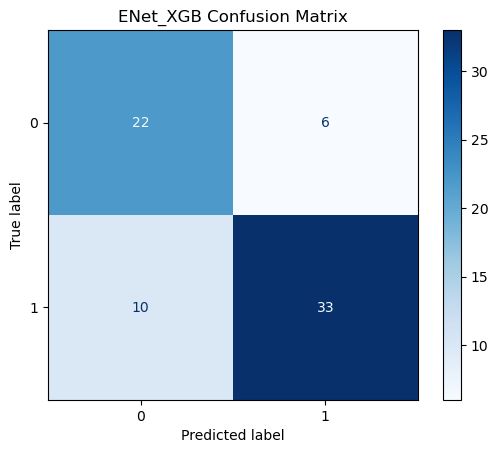

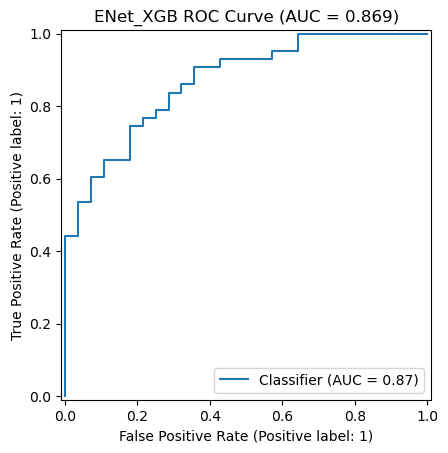


🔍 ENet_XGB SHAP 계산 중...

🔹 ENet_XGB SHAP 중요도 상위 40개


,feature,mean_abs_shap
6,student_interact,1.349631
4,prof_passion,1.173097
3,prof_access,1.102445
0,course_variety,1.021396
8,time_eff,0.906999
2,peer_event,0.791792
7,theory_cls,0.720760
5,prof_personal,0.702201
1,peer_advice,0.469476


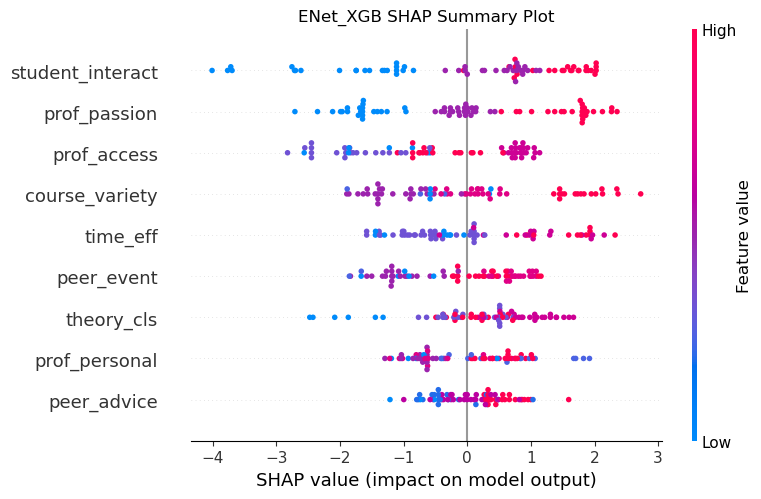



===== RFECV_RF =====
Confusion Matrix:


<Figure size 800x600 with 0 Axes>

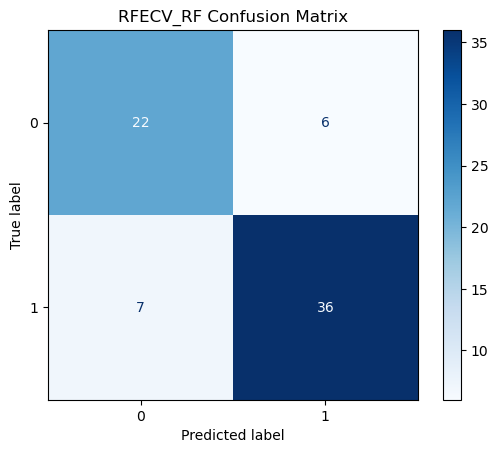

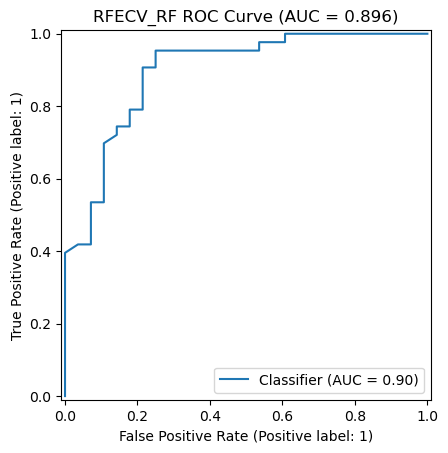


🔍 RFECV_RF SHAP 계산 중...

🔹 RFECV_RF SHAP 중요도 상위 40개


,feature,mean_abs_shap
25,prof_passion,0.061069
28,student_interact,0.054217
5,course_variety,0.042435
19,prof_access,0.040874
16,peer_event,0.034920
1,car_spt,0.025105
29,students_diligent,0.024463
32,theory_cls,0.017294
13,peer_advice,0.015980
26,prof_personal,0.015845


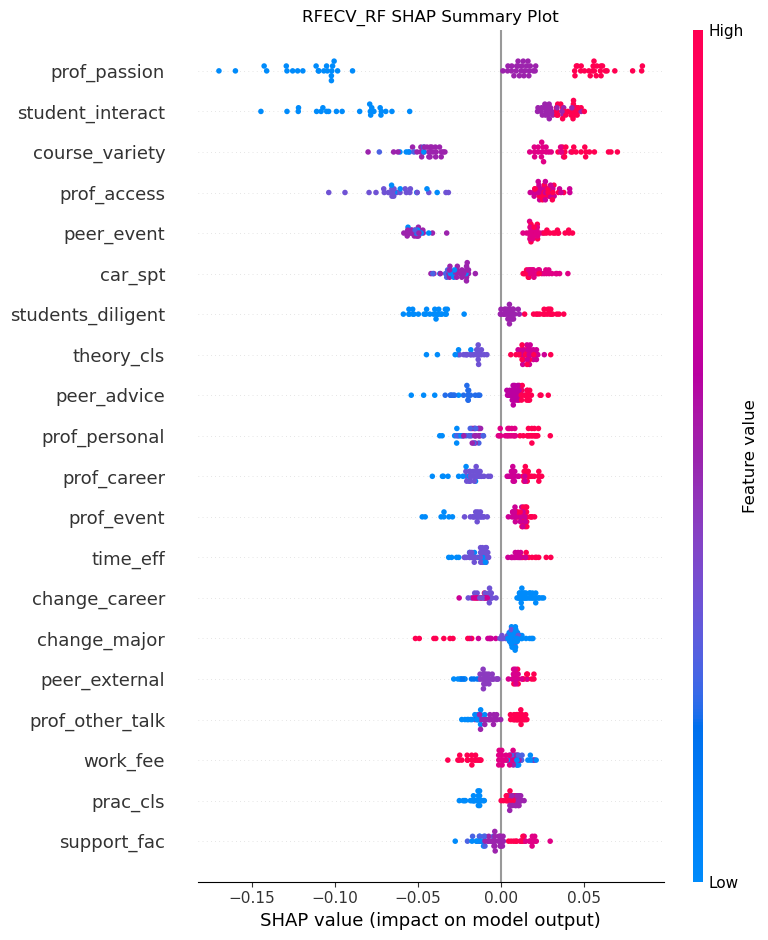

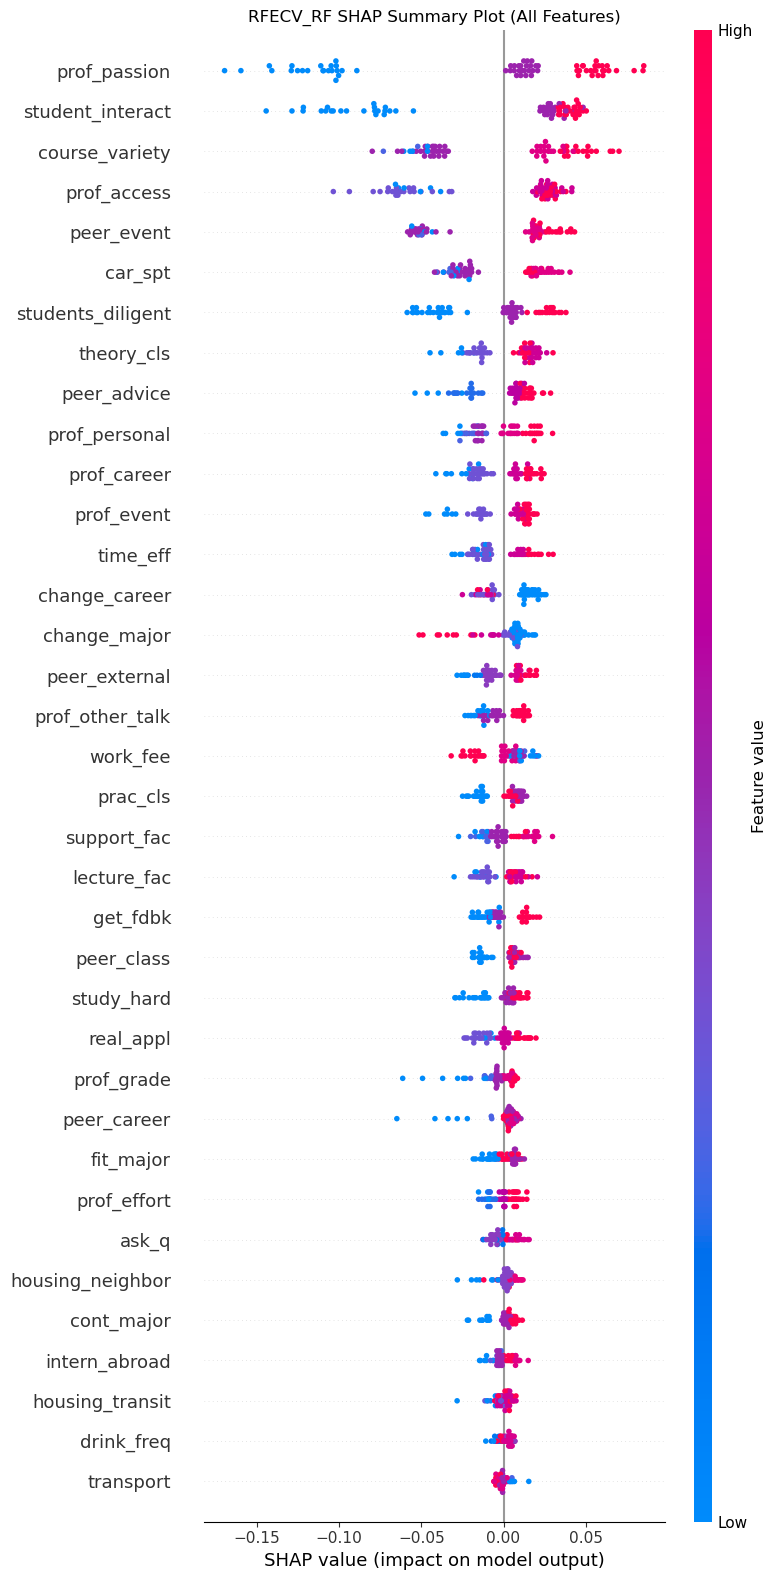

In [7]:
# ======================================
# ✅ 모델 집중 관찰: ENet_XGB / RFECV_RF
# - 최종 후보 모델을 대상으로 세부 성능 및 SHAP 해석 수행
# ======================================

import matplotlib.pyplot as plt
import shap
import pandas as pd
import numpy as np
from sklearn.metrics import ConfusionMatrixDisplay, RocCurveDisplay, roc_auc_score
from xgboost import XGBClassifier
from sklearn.ensemble import RandomForestClassifier

RANDOM_STATE = 42

# -------------------------
# 1) 집중 관찰할 모델 정의
# -------------------------
# - ElasticNet 기반 변수 → XGBoost 모델 학습
# - RFECV 기반 변수 → RandomForest 학습
# - 이유: 각 변수세트에서 최종 composite-score 상위 모델이기 때문
focus_models = {
    "ENet_XGB": {
        "model": XGBClassifier(
            n_estimators=300,              # 충분한 트리 수로 안정적 예측
            random_state=RANDOM_STATE,     # 재현성 보장
            eval_metric='logloss',         # 이진분류 기본 손실
            use_label_encoder=False,       # 경고 제거 옵션
            n_jobs=-1                      # CPU 병렬 처리
        ),
        "X_train": X_train_en,
        "X_test": X_test_en,
        "y_train": y_train_en,
        "y_test": y_test_en
    },
    "RFECV_RF": {
        "model": RandomForestClassifier(
            n_estimators=300,              # 충분한 에스티메이터 수
            random_state=RANDOM_STATE,
            n_jobs=-1
        ),
        "X_train": X_train_rf,
        "X_test": X_test_rf,
        "y_train": y_train_rf,
        "y_test": y_test_rf
    }
}

# -------------------------
# 2) 모델별 집중 분석 + SHAP
# -------------------------
for name, info in focus_models.items():

    print(f"\n\n===== {name} =====")

    model = info["model"]
    X_train = info["X_train"]
    X_test = info["X_test"]
    y_train = info["y_train"]
    y_test = info["y_test"]

    # -------------------------
    # 모델 학습
    # -------------------------
    # - Test 데이터는 절대 관여하지 않음 (누수 방지)
    model.fit(X_train, y_train)

    # -------------------------
    # 혼동행렬
    # -------------------------
    # - 모델의 분류 판단 중 실제/예측 차이를 직관적으로 확인
    print("Confusion Matrix:")
    ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap="Blues")
    plt.title(f"{name} Confusion Matrix")
    plt.show()

    # -------------------------
    # ROC Curve (AUC)
    # -------------------------
    # - 모델의 분류 임계값에 따른 민감도/특이도 관계 시각화
    try:
        y_score = model.predict_proba(X_test)[:, 1]   # 확률 기반 점수
    except:
        y_score = model.decision_function(X_test)     # 확률 제공 불가 모델 대응

    auc = roc_auc_score(y_test, y_score)

    RocCurveDisplay.from_predictions(y_test, y_score)
    plt.title(f"{name} ROC Curve (AUC = {auc:.3f})")
    plt.show()

    # -------------------------
    # SHAP 계산 (Tree 기반 모델용)
    # -------------------------
    # - SHAP(TreeExplainer)는 XGB / RF 모두 처리 가능
    print(f"\n🔍 {name} SHAP 계산 중...")

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test)

    # XGBoost의 shap_values 형식이 리스트로 반환될 경우 대비
    if isinstance(shap_values, list):
        shap_values = shap_values[1]  # 양성(1) 클래스 기준 SHAP 값 사용

    # 3D 구조(XGB 일부 버전) → 2D로 압축
    if isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
        shap_values = shap_values[:, :, 1]

    # 변수별 평균 절대 SHAP (Feature Importance)
    mean_abs_shap = np.abs(shap_values).mean(axis=0)

    shap_importance = pd.DataFrame({
        "feature": X_test.columns,
        "mean_abs_shap": mean_abs_shap
    }).sort_values("mean_abs_shap", ascending=False)

    print(f"\n🔹 {name} SHAP 중요도 상위 40개")
    display(shap_importance.head(40))

    # -------------------------
    # SHAP Summary Plot (기본)
    # -------------------------
    # - 변수 효과량 + 분포를 동시에 시각화
    plt.figure(figsize=(8, 6))
    shap.summary_plot(shap_values, X_test, plot_type="dot", show=False)
    plt.title(f"{name} SHAP Summary Plot")
    plt.tight_layout()
    plt.show()

    # -------------------------
    # SHAP Summary Plot (전체 변수)
    # -------------------------
    # - 최대 171개 변수까지 모두 표시하도록 max_display 조정
    plt.figure(figsize=(8, 6))
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="dot",
    max_display=len(X_test.columns),   # 전체 변수 표시
    show=False
)
plt.title(f"{name} SHAP Summary Plot (All Features)")
plt.tight_layout()
plt.show()


# 6. 변수별 KDE, 상관관계 등 

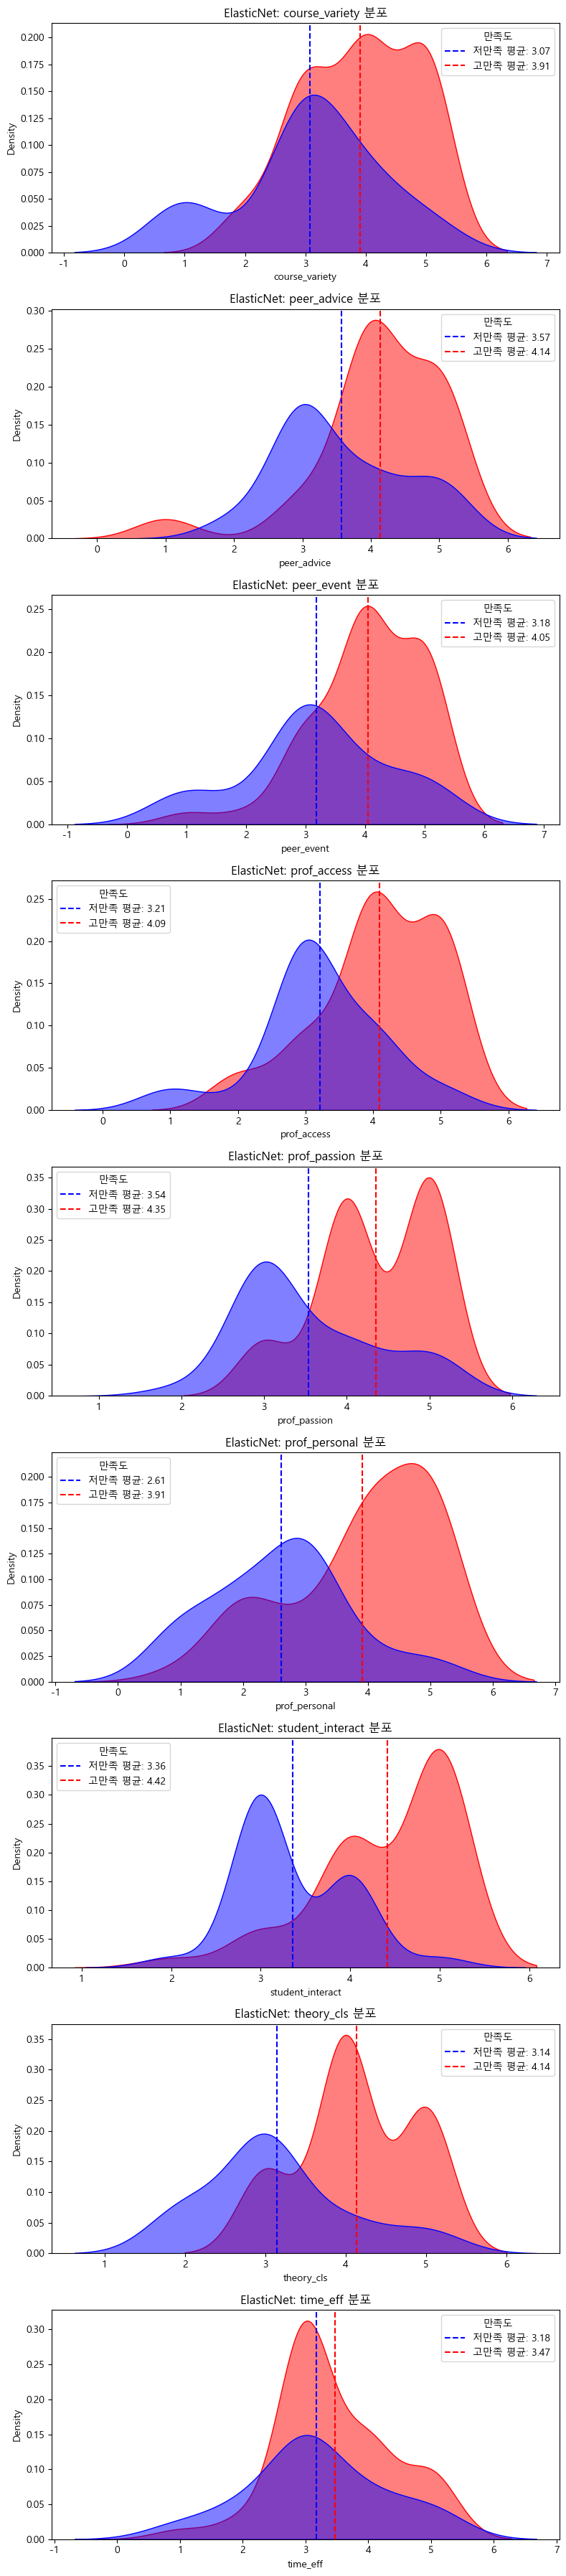

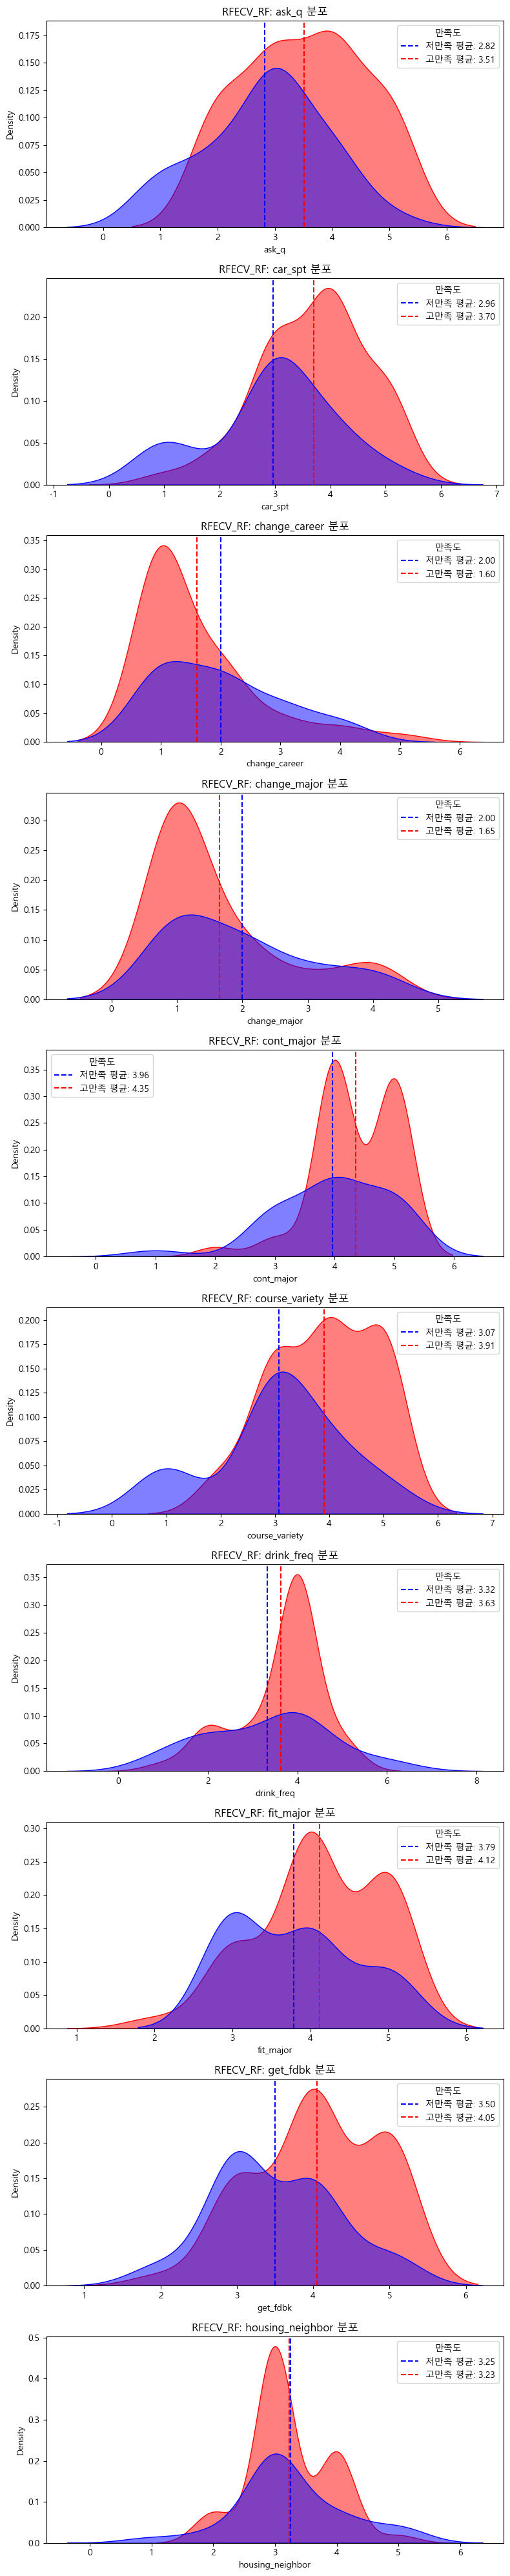

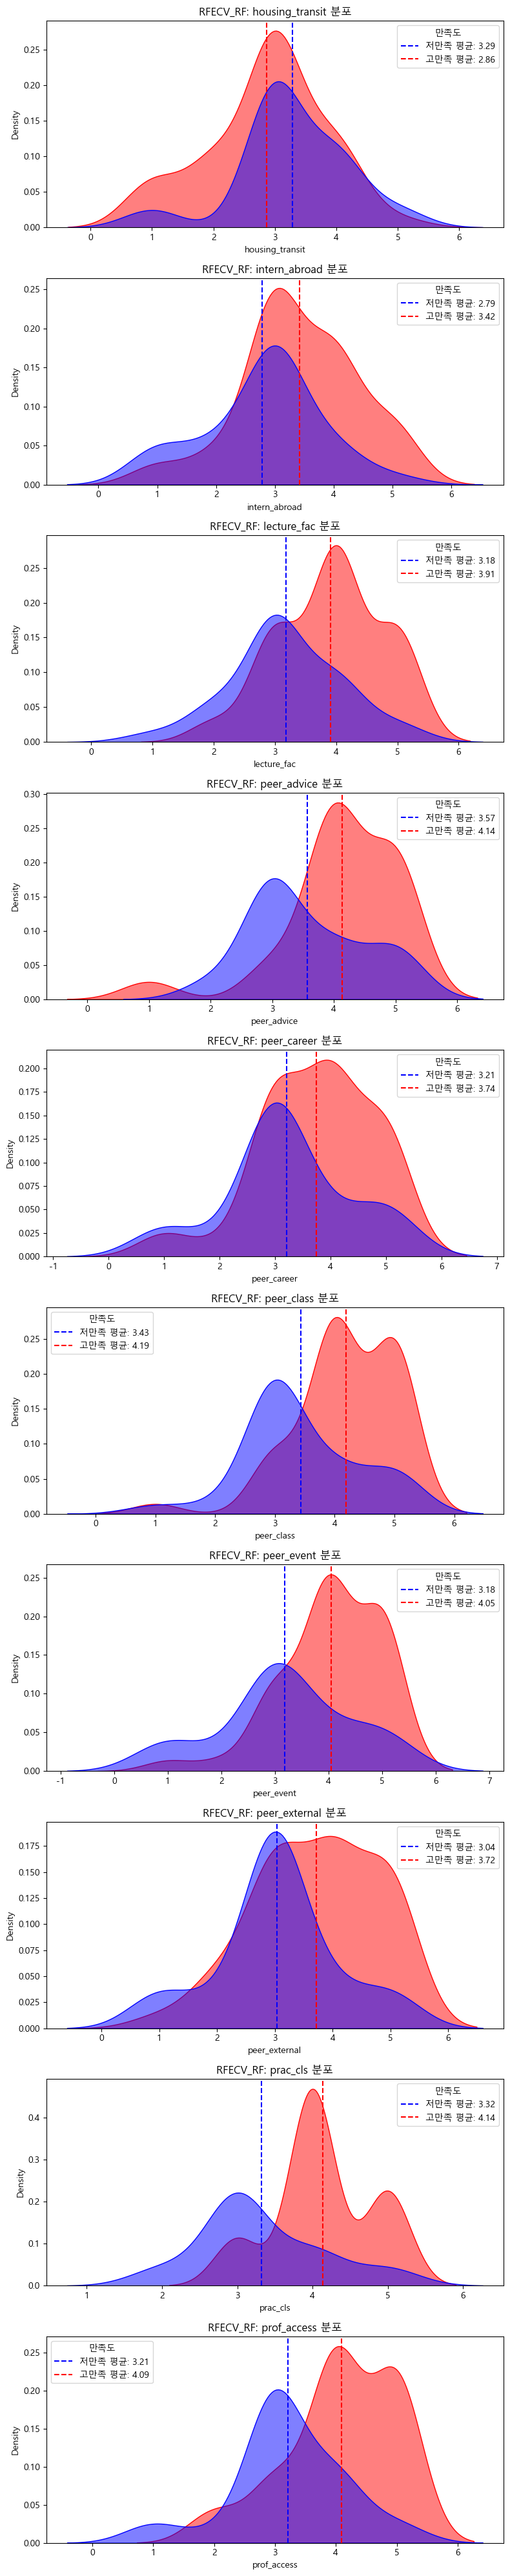

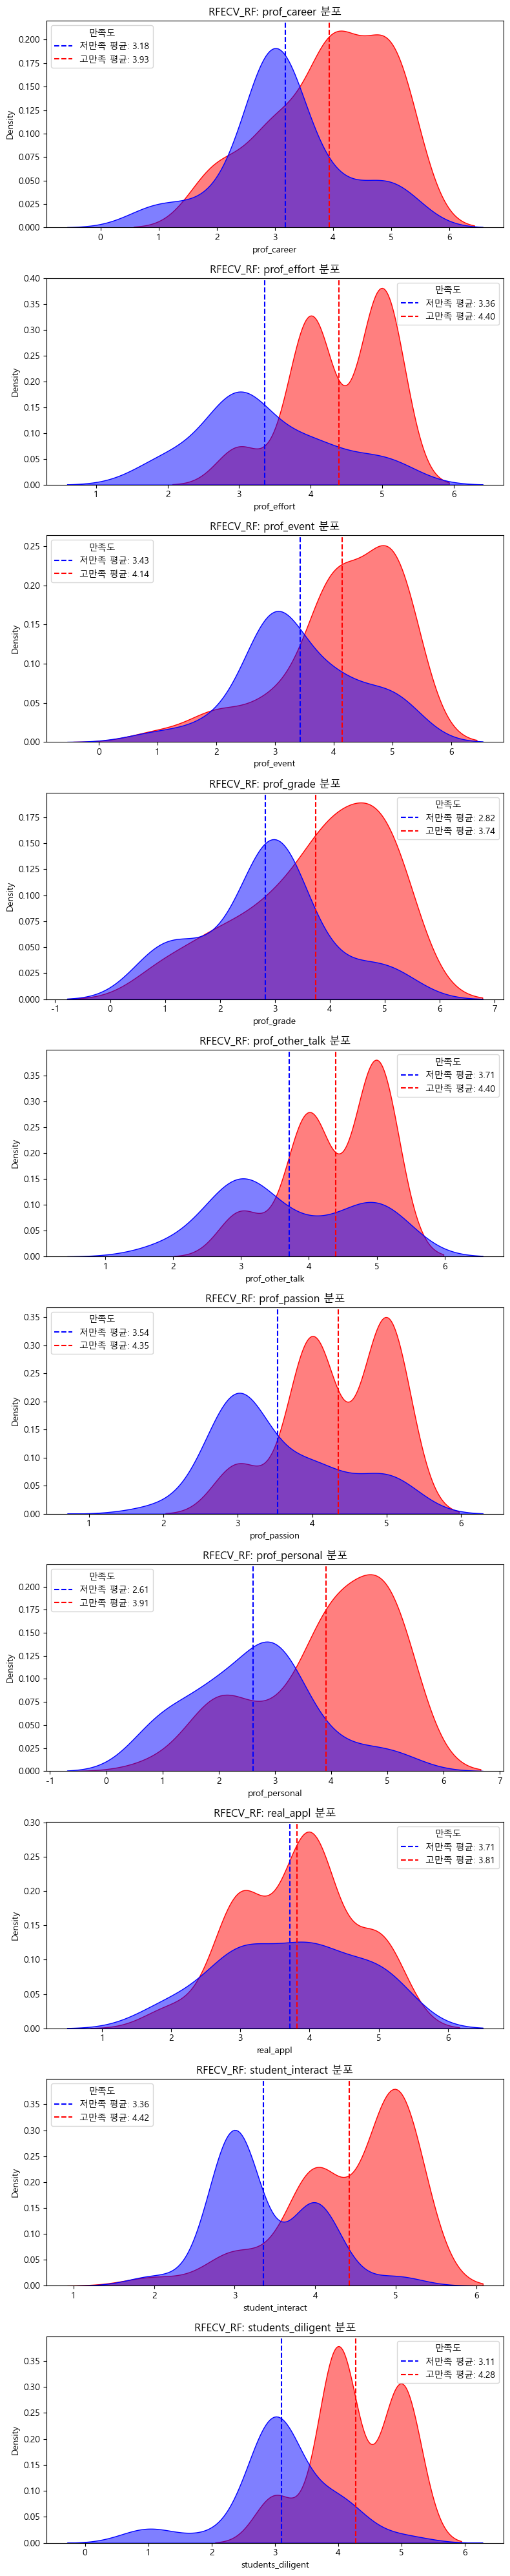

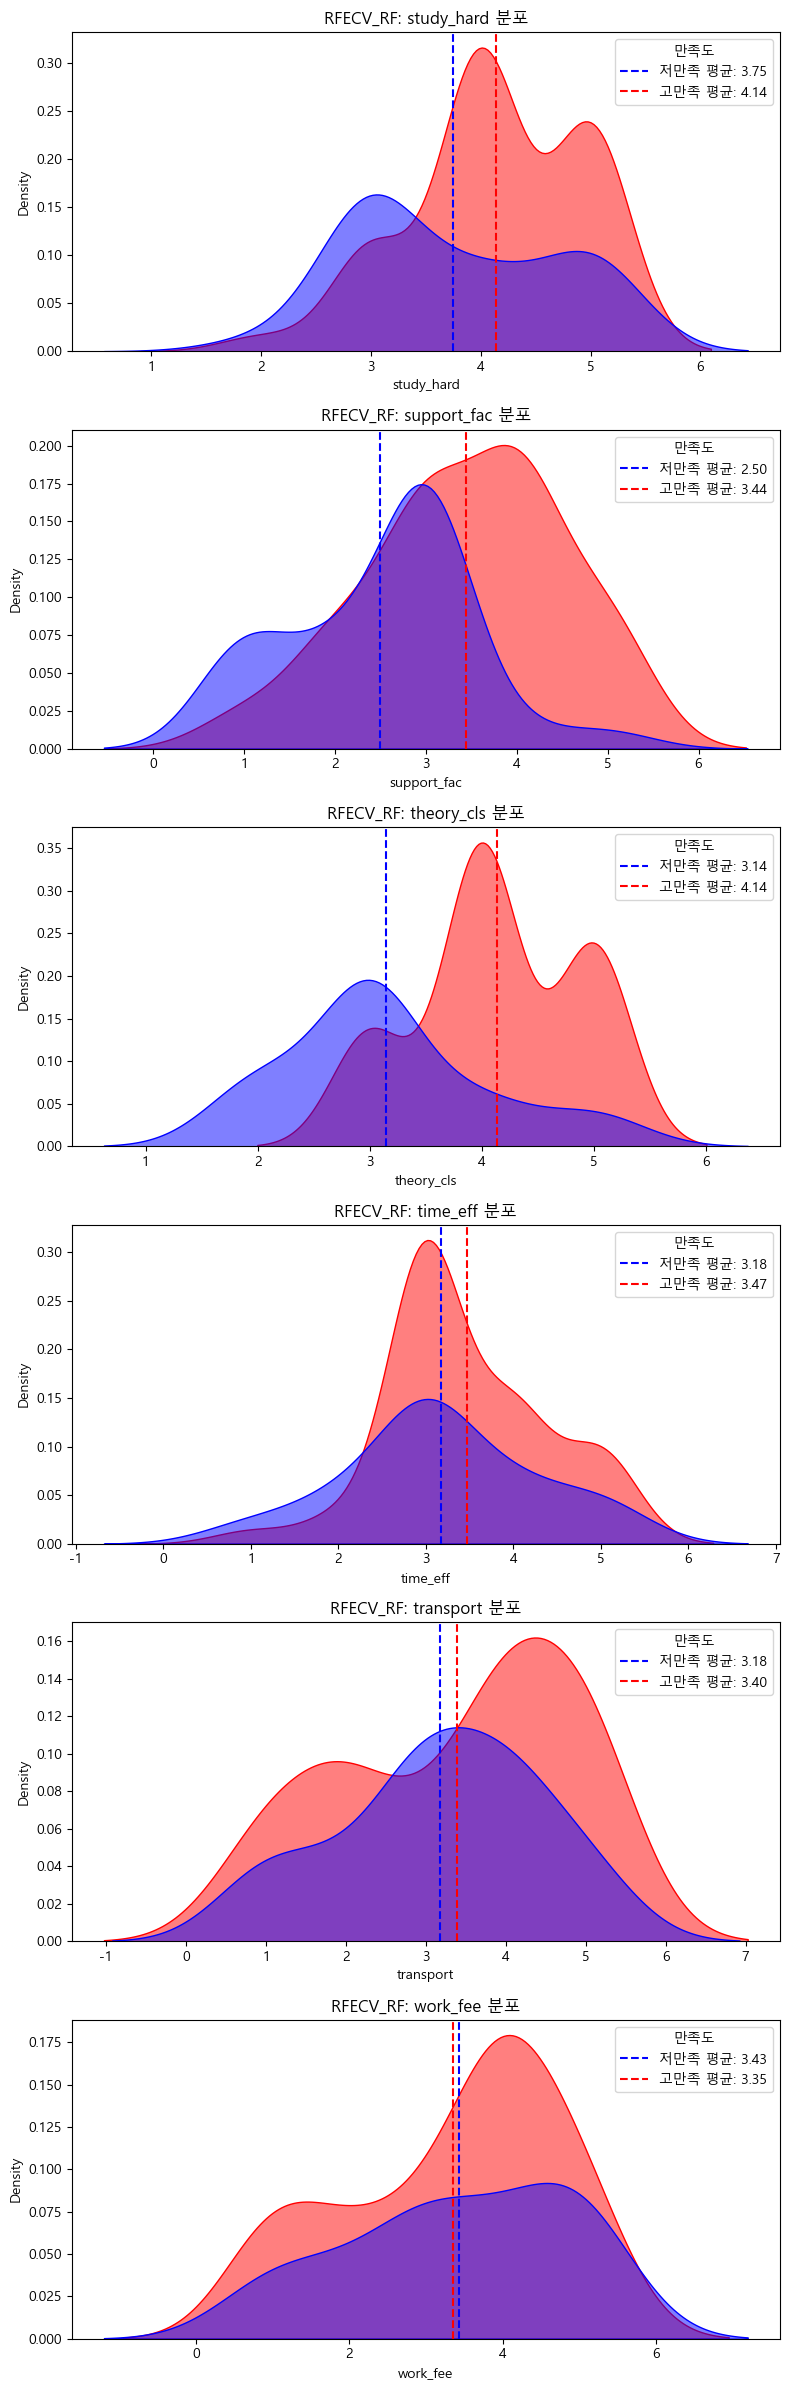

In [8]:
# ======================================
# 6️⃣ 변수 분포 비교(KDE Plot): 고만족 vs 저만족
# ======================================

import matplotlib.pyplot as plt
import matplotlib

# -------------------------
# (1) 한글 폰트 설정
#    - Windows 환경을 고려하여 'Malgun Gothic' 사용
# -------------------------
matplotlib.rcParams['font.family'] = 'Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False  # 음수 기호 깨짐 방지

import matplotlib.pyplot as plt
import seaborn as sns

# -------------------------
# (2) 변수별 KDE Plot 함수 정의
#    - y_series 값(0=저만족, 1=고만족)에 따라 색을 구분
#    - 변수 10개씩 묶어 자동 분할 표시
#    - 각 분포에 평균선 추가하여 시각적으로 차이 확인 용이
# -------------------------
def plot_kde_by_group(X_df, y_series, title_prefix=""):
    vars_ = X_df.columns
    n_vars = len(vars_)
    
    max_per_fig = 10  # 한 그래프당 최대 10개씩
    for start in range(0, n_vars, max_per_fig):
        end = min(start + max_per_fig, n_vars)
        vars_subset = vars_[start:end]
        
        fig, axes = plt.subplots(len(vars_subset), 1, figsize=(8, 4 * len(vars_subset)))
        if len(vars_subset) == 1:
            axes = [axes]  # 변수 1개인 경우 리스트 형태로 변환
            
        for i, var in enumerate(vars_subset):
            
            # -------------------------
            # (2-1) KDE Plot
            # -------------------------
            sns.kdeplot(
                data=X_df,
                x=var,
                hue=y_series,        # 0/1 그룹 색상 구분
                fill=True,
                common_norm=True,    # 두 그룹 크기 비교 용이
                palette={0: "blue", 1: "red"},
                alpha=0.5,
                ax=axes[i]
            )
            
            # -------------------------
            # (2-2) 평균값 수직선 표시
            # -------------------------
            mean_0 = X_df[y_series==0][var].mean()
            mean_1 = X_df[y_series==1][var].mean()
            axes[i].axvline(mean_0, color='blue', linestyle='--', label=f'저만족 평균: {mean_0:.2f}')
            axes[i].axvline(mean_1, color='red', linestyle='--', label=f'고만족 평균: {mean_1:.2f}')
            
            axes[i].set_title(f"{title_prefix}{var} 분포")
            axes[i].set_xlabel(var)
            axes[i].set_ylabel("Density")
            axes[i].legend(title="만족도")
        
        plt.tight_layout()
        plt.show()


# ======================================
# (3) ElasticNet 선택 변수 KDE
#    - ENet_XGB 모델에서 사용된 변수들만 plotting
# ======================================
plot_kde_by_group(
    X_df = focus_models["ENet_XGB"]["X_test"], 
    y_series = focus_models["ENet_XGB"]["y_test"], 
    title_prefix="ElasticNet: "
)

# ======================================
# (4) RFECV 기반 RandomForest 선택 변수 KDE
# ======================================
plot_kde_by_group(
    X_df = focus_models["RFECV_RF"]["X_test"], 
    y_series = focus_models["RFECV_RF"]["y_test"], 
    title_prefix="RFECV_RF: "
)




===== ElasticNet 변수 세트: 상관관계 분석 =====


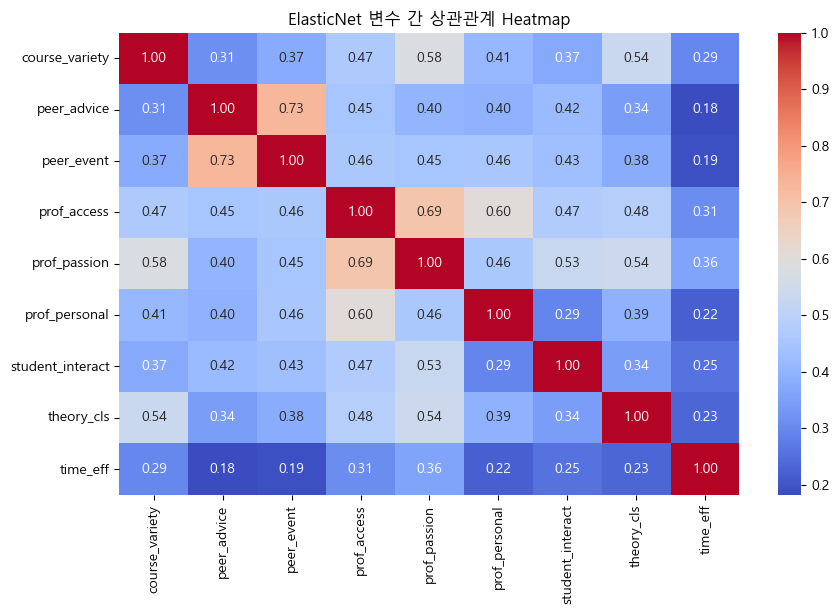


ElasticNet VIF 지수:


,feature,VIF
4,prof_passion,64.871237
3,prof_access,44.442570
1,peer_advice,33.222658
6,student_interact,31.607171
2,peer_event,31.376062
7,theory_cls,23.444616
0,course_variety,19.450819
8,time_eff,15.442712
5,prof_personal,14.766452




===== RFECV_RF 변수 세트: 상관관계 분석 =====


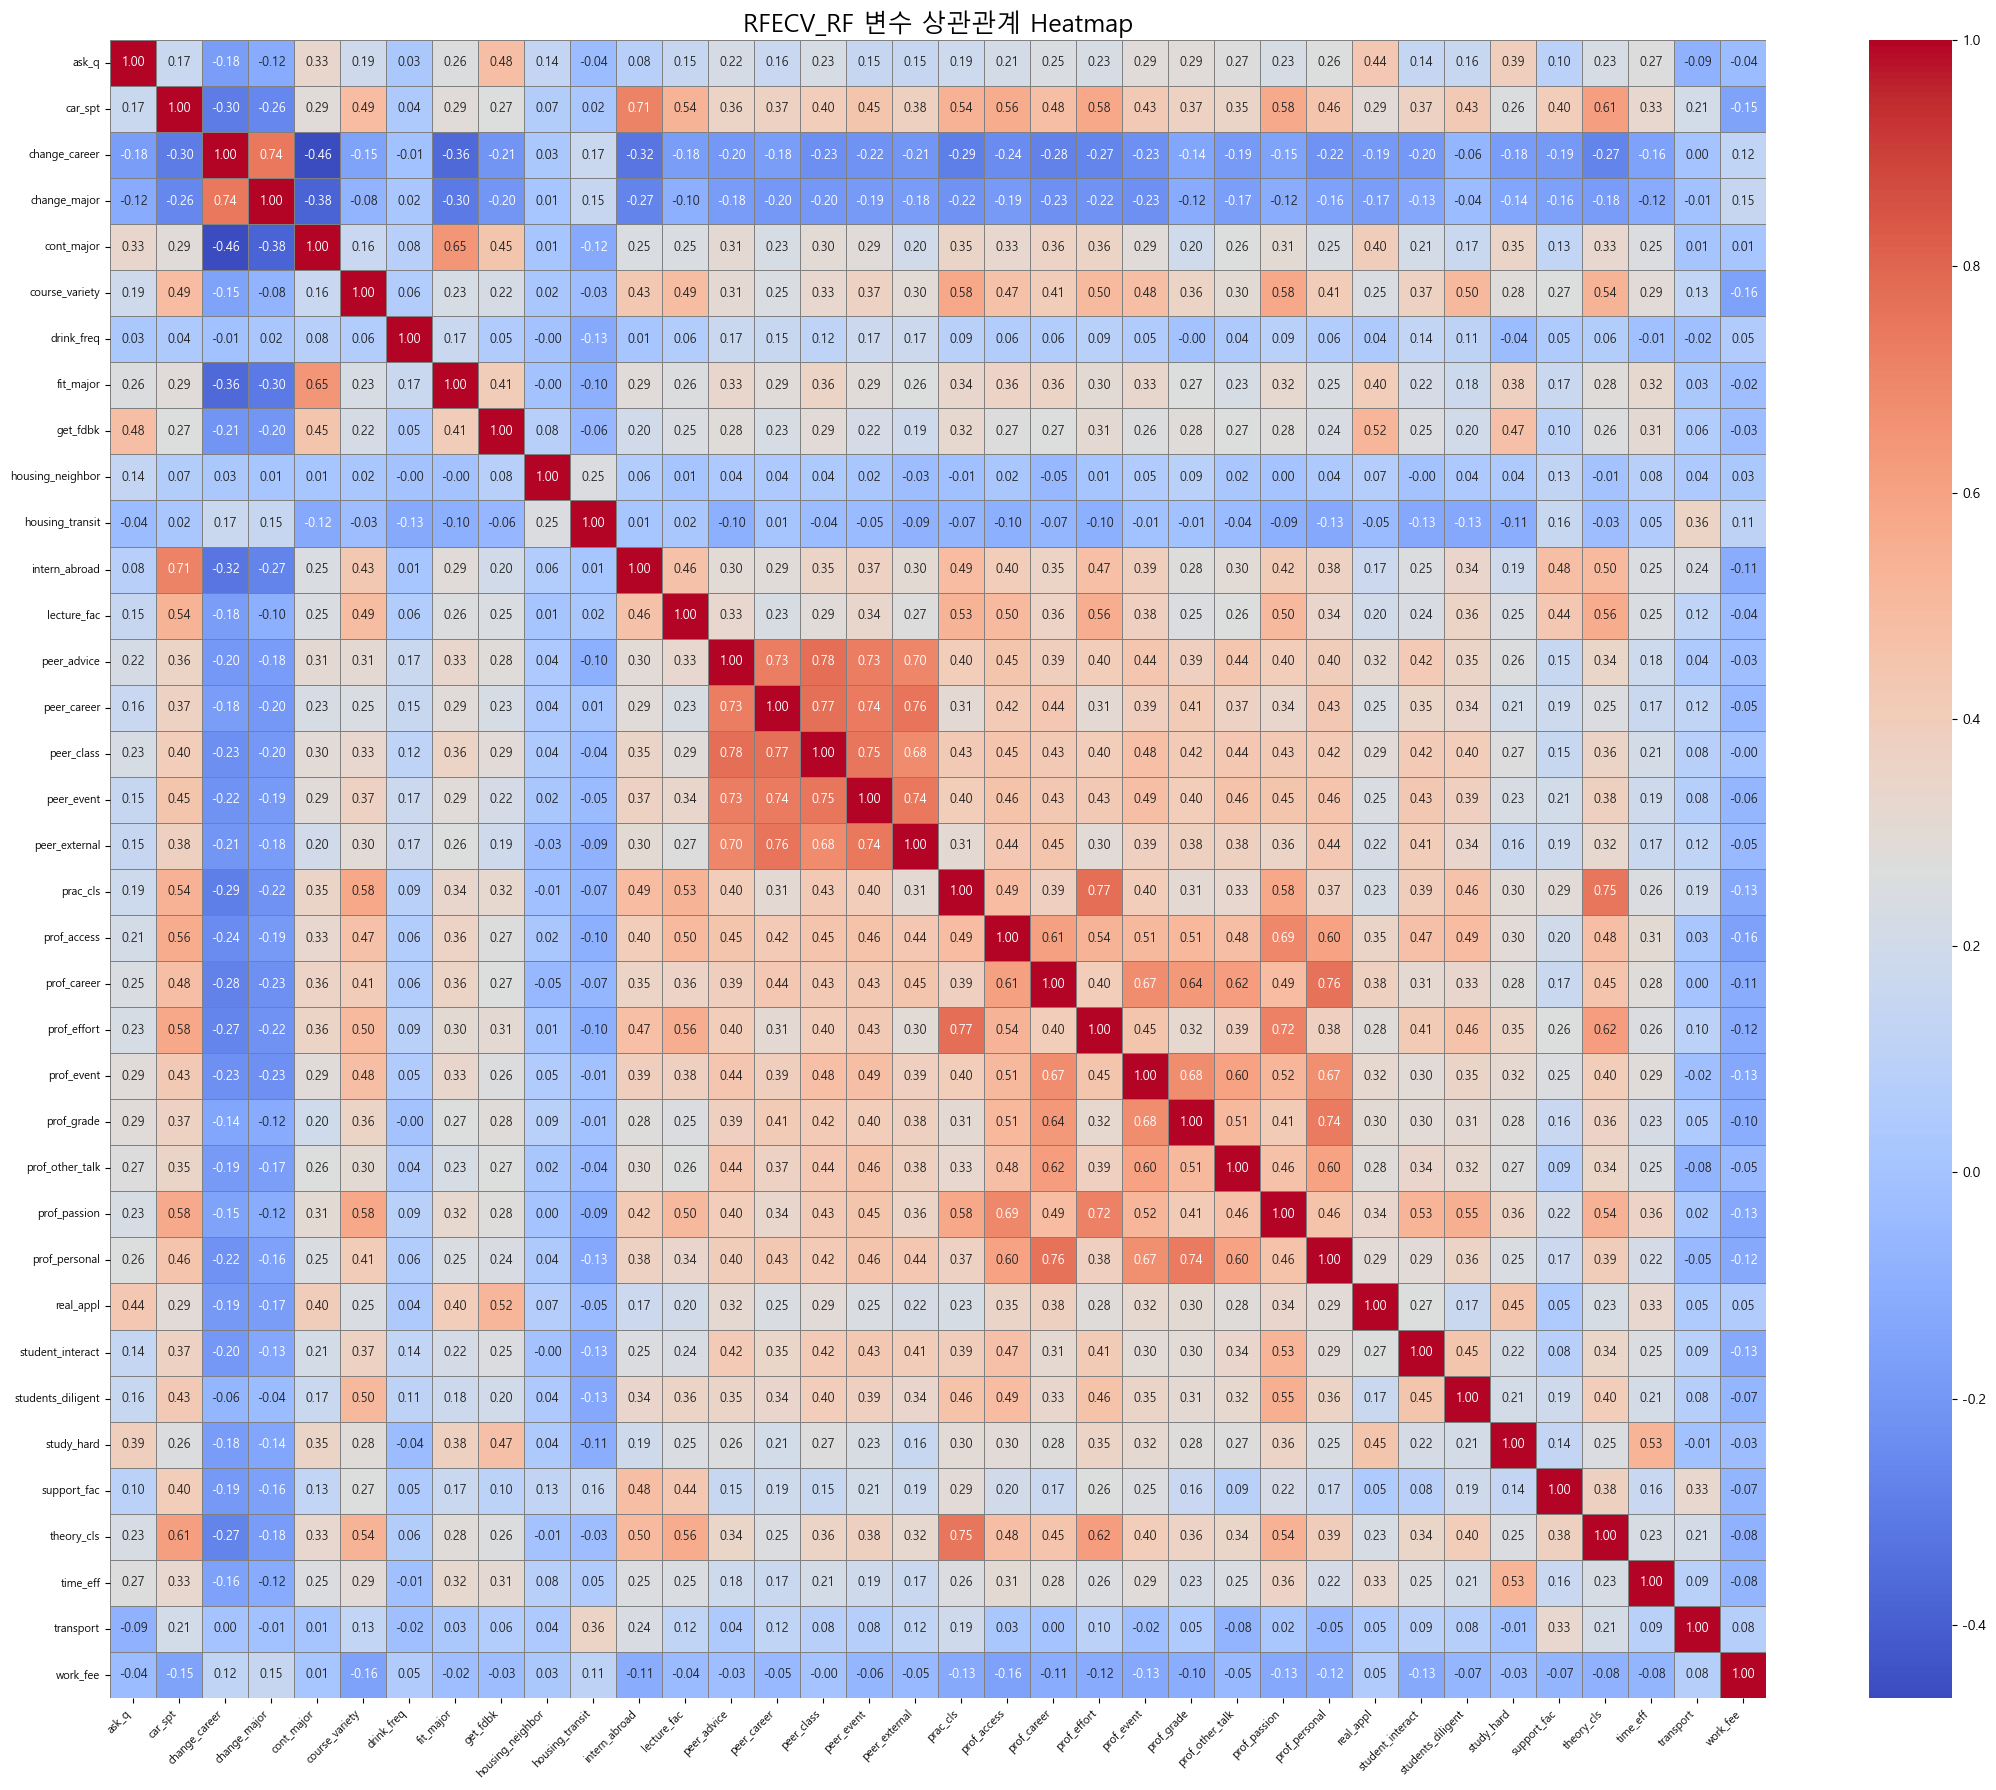

In [9]:
# ==========================================
# 📌 ENet / RFECV_RF 변수 세트: 상관관계 + VIF 분석
# ==========================================

import seaborn as sns
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm

# -------------------------
# VIF 계산 함수
# -------------------------
def compute_vif(df):
    vif_data = pd.DataFrame()
    vif_data["feature"] = df.columns
    vif_data["VIF"] = [
        variance_inflation_factor(df.values, i) for i in range(df.shape[1])
    ]
    return vif_data.sort_values("VIF", ascending=False)


# -------------------------
# 📌 1) ElasticNet 변수 세트
# -------------------------
print("\n\n===== ElasticNet 변수 세트: 상관관계 분석 =====")

X_enet_corr = df[elasticnet_vars]

# 🔹 상관관계 Heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(X_enet_corr.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("ElasticNet 변수 간 상관관계 Heatmap")
plt.show()

# 🔹 VIF 지수
enet_vif = compute_vif(X_enet_corr)
print("\nElasticNet VIF 지수:")
display(enet_vif)



# -------------------------
# 📌 2) RFECV_RF 변수 세트
# -------------------------
print("\n\n===== RFECV_RF 변수 세트: 상관관계 분석 =====")

X_rf_corr = df[rfecv_rf_vars]

plt.figure(figsize=(22, 18))  # 🔥 훨씬 큰 크기
corr = df[rfecv_rf_vars].corr()

sns.heatmap(
    corr,
    cmap="coolwarm",
    annot=True,        # 🔥 숫자 표시
    fmt=".2f",         # 🔥 소수 2자리
    annot_kws={"size": 9},  # 🔥 수치 글씨 크기
    linewidths=0.5,    # 🔥 셀 구분선 추가 (더 선명)
    linecolor="gray"
)

plt.title("RFECV_RF 변수 상관관계 Heatmap", fontsize=18)

plt.xticks(fontsize=8, rotation=45, ha="right")  # 🔥 X축 글씨 개선
plt.yticks(fontsize=8)

plt.tight_layout()  # 🔥 글씨 겹침 방지
plt.show()
